# ✈️ Airline Analytics — Machine Learning
**Esprit Engineering — 3ème année — 2026**

---

## Objectifs du projet
| Axe | Objectif actuel | Cible |
|-----|----------------|-------|
| Satisfaction passagers | 57% | **73.1%** |
| Fidélisation (Loyalty) | 30% | **40%** |

## Plan d'analyse ML
1. **Connexion DWH** — SQL Server `DWH_DB`
2. **EDA** — Exploration des données
3. **AXE SATISFACTION** — Classification + Clustering
4. **AXE LOYALTY** — Prédiction du churn + Segmentation RFM
5. **NLP** — Analyse des profils textuels de service
6. **Synthèse KPIs** — Résultats vs objectifs


## 0. Configuration & Imports

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, urllib
from pathlib import Path
warnings.filterwarnings('ignore')

from sqlalchemy import create_engine, text

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingRegressor)
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              mean_squared_error, r2_score)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
import xgboost as xgb
from imblearn.over_sampling import SMOTE

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Packages chargés")
print(f"   numpy {np.__version__}  |  pandas {pd.__version__}  |  xgboost {xgb.__version__}")


✅ Packages chargés
   numpy 1.26.4  |  pandas 2.2.2  |  xgboost 3.2.0


## 1. Connexion à DWH_DB (SQL Server)

In [135]:
# ── Connexion SQL Server avec authentification Windows ──────────────────────
SERVER   = r"MEA-JJG4XL3\DEV3"
DATABASE = "DWH_DB"

params = urllib.parse.quote_plus(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"Trusted_Connection=yes;"
)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}", fast_executemany=True)

# Test connexion
with engine.connect() as conn:
    version = conn.execute(text("SELECT @@VERSION")).fetchone()[0].split('\n')[0]
    print(f"✅ Connexion établie : {version}")


✅ Connexion établie : Microsoft SQL Server 2022 (RTM) - 16.0.1000.6 (X64) 


## 2. Chargement des données depuis DWH_DB

In [136]:
# ── FACT_PASSENGER_SATISFACTION + DIM_TRAVEL ─────────────────────────────────
SQL_SAT = """
SELECT
    f.SK_Satisfaction,
    f.SK_Travel,
    f.Gender,
    f.CustomerType,
    f.Age,
    f.FlightDistance,
    f.DepartureDelay,
    f.ArrivalDelay,
    f.TimeConvenience,
    f.OnlineBooking,
    f.CheckinService,
    f.OnlineBoarding,
    f.GateLocation,
    f.OnboardService,
    f.SeatComfort,
    f.LegRoom,
    f.Cleanliness,
    f.FoodAndDrink,
    f.InFlightService,
    f.InFlightWifi,
    f.InFlightEntertainment,
    f.BaggageHandling,
    f.AvgServiceScore,
    f.Satisfaction,
    f.Satisfaction_Flag,
    t.TypeOfTravel,
    t.Class,
    t.TravelProfile
FROM dbo.FACT_PASSENGER_SATISFACTION f
LEFT JOIN dbo.DIM_TRAVEL t
    ON f.SK_Travel = t.SK_Travel AND t.SK_Travel > 0
"""
df_sat = pd.read_sql(SQL_SAT, engine)
print(f"✅ FACT_PASSENGER_SATISFACTION : {df_sat.shape[0]:,} lignes × {df_sat.shape[1]} colonnes")
df_sat.head(3)


✅ FACT_PASSENGER_SATISFACTION : 129,880 lignes × 28 colonnes


,SK_Satisfaction,SK_Travel,Gender,CustomerType,Age,FlightDistance,DepartureDelay,ArrivalDelay,TimeConvenience,OnlineBooking,...,InFlightService,InFlightWifi,InFlightEntertainment,BaggageHandling,AvgServiceScore,Satisfaction,Satisfaction_Flag,TypeOfTravel,Class,TravelProfile
0,1,4,Male,First-time,48,821,2,5.0,3,3,...,5,3,5,5,3.85,Neutral or Dissatisfied,False,Business,Business,Business - Business
1,2,4,Female,Returning,35,821,26,39.0,2,2,...,5,2,5,5,3.78,Satisfied,True,Business,Business,Business - Business
2,3,4,Male,Returning,41,853,0,0.0,4,4,...,3,4,3,3,3.92,Satisfied,True,Business,Business,Business - Business


In [137]:
# ── DIM_CUSTOMER + DIM_LOYALTY_CARD + DIM_GEOGRAPHY ──────────────────────────
SQL_CUST = """
SELECT
    c.SK_Customer,
    c.LoyaltyNumber,
    c.Gender,
    c.Education,
    c.MaritalStatus,
    TRY_CAST(NULLIF(c.Salary, N'Unknown') AS DECIMAL(18,2)) AS Salary,
    c.CLV,
    c.EnrollmentType,
    c.EnrollmentYear,
    c.EnrollmentMonth,
    c.CancellationYear,
    c.CancellationMonth,
    c.IsChurned,
    c.EnrollmentDate,
    c.SCD_IsCurrent,
    lc.LoyaltyCard,
    g.Country,
    g.Province,
    g.City
FROM dbo.DIM_CUSTOMER c
LEFT JOIN dbo.DIM_LOYALTY_CARD lc ON c.SK_LoyaltyCard = lc.SK_LoyaltyCard
LEFT JOIN dbo.DIM_GEOGRAPHY g     ON c.SK_Geography   = g.SK_Geography
WHERE c.SK_Customer > 0
  AND c.SCD_IsCurrent = 1
"""
df_cust = pd.read_sql(SQL_CUST, engine)
print(f"✅ DIM_CUSTOMER (version courante) : {df_cust.shape[0]:,} membres")
df_cust.head(3)


✅ DIM_CUSTOMER (version courante) : 16,737 membres


,SK_Customer,LoyaltyNumber,Gender,Education,MaritalStatus,Salary,CLV,EnrollmentType,EnrollmentYear,EnrollmentMonth,CancellationYear,CancellationMonth,IsChurned,EnrollmentDate,SCD_IsCurrent,LoyaltyCard,Country,Province,City
0,1,529098,Female,College,Divorced,NaN,3974.86,Standard,2017,10,NaN,NaN,False,2017-10-01,True,Star,Canada,British Columbia,Vancouver
1,2,265297,Female,Bachelor,Married,60519.0,3978.67,Standard,2018,7,NaN,NaN,False,2018-07-01,True,Star,Canada,Manitoba,Winnipeg
2,3,567875,Female,Bachelor,Married,102457.0,3979.72,Standard,2017,5,NaN,NaN,False,2017-05-01,True,Star,Canada,Quebec,Quebec City


In [138]:
# ── FACT_FLIGHT_ACTIVITY + DIM_DATE ──────────────────────────────────────────
SQL_ACT = """
SELECT
    f.SK_Customer,
    f.TotalFlights,
    f.Distance,
    f.PointsAccumulated,
    f.PointsRedeemed,
    f.DollarCostPointsRedeemed,
    d.Year,
    d.MonthNumber AS Month
FROM dbo.FACT_FLIGHT_ACTIVITY f
LEFT JOIN dbo.DIM_DATE d ON f.SK_Date = d.SK_Date AND d.SK_Date > 0
WHERE f.SK_Customer > 0
"""
df_activity = pd.read_sql(SQL_ACT, engine)
print(f"✅ FACT_FLIGHT_ACTIVITY : {df_activity.shape[0]:,} lignes")

# Aggregation keys for recency
df_activity['YearMonth'] = df_activity['Year'] * 100 + df_activity['Month']

# Aggregation par client
act_agg = df_activity.groupby('SK_Customer').agg(
    TotalFlights     = ('TotalFlights',            'sum'),
    TotalDistance    = ('Distance',                'sum'),
    PointsAcc        = ('PointsAccumulated',       'sum'),
    PointsRed        = ('PointsRedeemed',          'sum'),
    DollarCost       = ('DollarCostPointsRedeemed','sum'),
    ActiveMonths     = ('TotalFlights',            'count'),
    LastYearMonth    = ('YearMonth',               'max')
).reset_index()

act_agg['LastYear'] = act_agg['LastYearMonth'] // 100
act_agg['LastMonth'] = act_agg['LastYearMonth'] % 100
global_ym = act_agg['LastYearMonth'].max()
act_agg['RecencyMonths'] = (global_ym // 100 - act_agg['LastYear']) * 12 + (global_ym % 100 - act_agg['LastMonth'])

# Jointure avec DIM_CUSTOMER
df_loy = df_cust.merge(act_agg, on='SK_Customer', how='left')
max_recency = act_agg['RecencyMonths'].max()
df_loy.fillna({'TotalFlights':0,'TotalDistance':0,'PointsAcc':0,'PointsRed':0,
               'DollarCost':0,'ActiveMonths':0,'RecencyMonths':max_recency}, inplace=True)
df_loy['RedemptionRate']     = df_loy['PointsRed'] / (df_loy['PointsAcc'] + 1)
df_loy['AvgFlightsPerMonth'] = df_loy['TotalFlights'] / (df_loy['ActiveMonths'] + 1)
df_loy['SpendPerFlight']     = df_loy['DollarCost'] / (df_loy['TotalFlights'] + 1)
df_loy['DistancePerFlight']  = df_loy['TotalDistance'] / (df_loy['TotalFlights'] + 1)
df_loy['PointsPerFlight']    = df_loy['PointsAcc'] / (df_loy['TotalFlights'] + 1)
df_loy['RedeemPerFlight']    = df_loy['PointsRed'] / (df_loy['TotalFlights'] + 1)

# Tenure months from enrollment date to last observed activity
global_last_date = pd.to_datetime(f"{global_ym//100}-{global_ym%100:02d}-01")
df_loy['EnrollmentDate'] = pd.to_datetime(df_loy['EnrollmentDate'], errors='coerce')
df_loy['TenureMonths'] = (
    (global_last_date.year - df_loy['EnrollmentDate'].dt.year) * 12 +
    (global_last_date.month - df_loy['EnrollmentDate'].dt.month)
)
df_loy['TenureMonths'] = df_loy['TenureMonths'].clip(lower=0)
df_loy['TenureMonths'] = df_loy['TenureMonths'].fillna(df_loy['TenureMonths'].median())
df_loy['FlightsPerTenureMonth'] = df_loy['TotalFlights'] / (df_loy['TenureMonths'] + 1)

print(f"✅ Dataset loyalty enrichi  : {df_loy.shape[0]:,} membres")
print(f"   Churned : {df_loy['IsChurned'].sum():,} ({df_loy['IsChurned'].mean()*100:.1f}%)")


✅ FACT_FLIGHT_ACTIVITY : 392,936 lignes
✅ Dataset loyalty enrichi  : 16,737 membres
   Churned : 2,067 (12.3%)


In [139]:
# ── Résumé des tables DWH chargées ───────────────────────────────────────────
print("=" * 55)
print("   DONNÉES CHARGÉES DEPUIS DWH_DB")
print("=" * 55)

with engine.connect() as conn:
    tables = ['FACT_PASSENGER_SATISFACTION','FACT_FLIGHT_ACTIVITY',
              'DIM_CUSTOMER','DIM_DATE','DIM_TRAVEL','DIM_LOYALTY_CARD','DIM_GEOGRAPHY']
    for t in tables:
        n = conn.execute(text(f"SELECT COUNT(*) FROM dbo.{t}")).fetchone()[0]
        print(f"   {t:<35s} : {n:>8,} lignes")
print("=" * 55)


   DONNÉES CHARGÉES DEPUIS DWH_DB
   FACT_PASSENGER_SATISFACTION         :  129,880 lignes
   FACT_FLIGHT_ACTIVITY                :  392,936 lignes
   DIM_CUSTOMER                        :   16,738 lignes
   DIM_DATE                            :    2,558 lignes
   DIM_TRAVEL                          :        7 lignes
   DIM_LOYALTY_CARD                    :        4 lignes
   DIM_GEOGRAPHY                       :       56 lignes


## 3. Analyse Exploratoire (EDA)

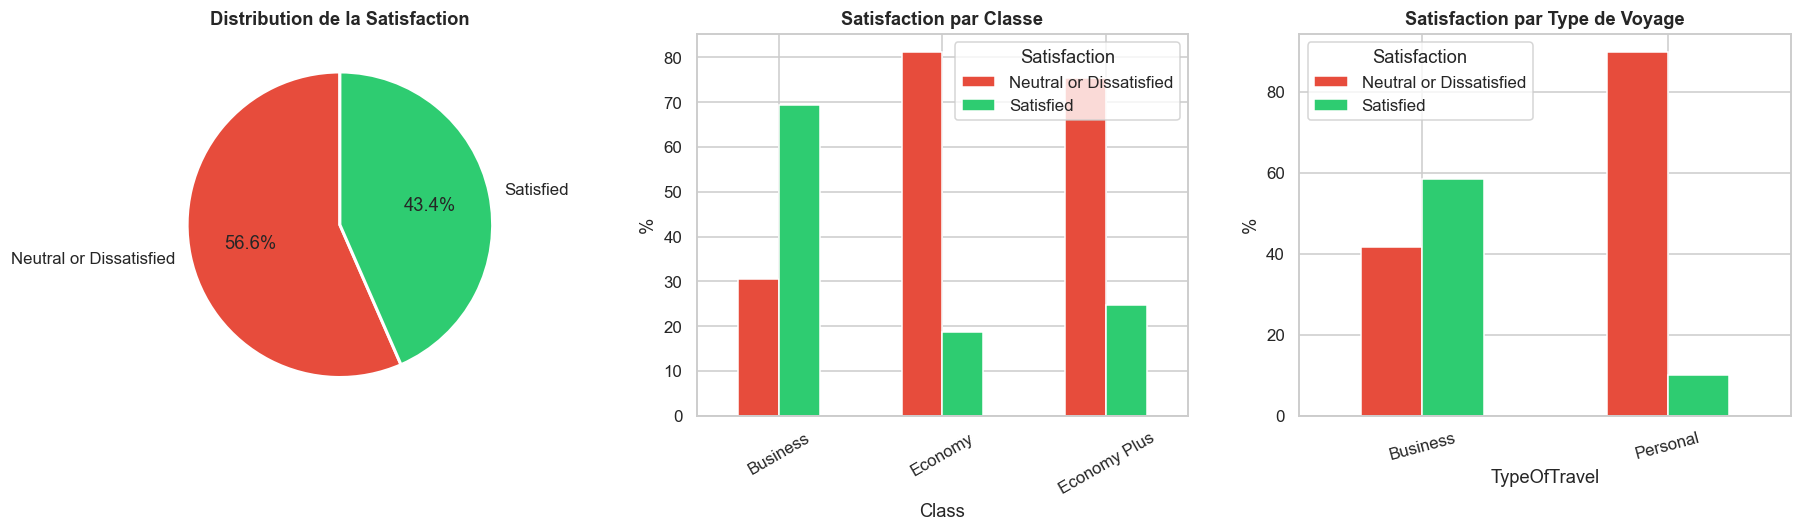


📊 Taux de satisfaction : 43.4%  |  Cible : 73.1%  |  Gap : +29.7%


In [140]:
# ── Distribution satisfaction ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors = ['#e74c3c','#2ecc71']

sat_counts = df_sat['Satisfaction'].value_counts()
axes[0].pie(sat_counts.values, labels=sat_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Distribution de la Satisfaction', fontweight='bold')

if 'Class' in df_sat.columns and df_sat['Class'].notna().any():
    ct = pd.crosstab(df_sat['Class'], df_sat['Satisfaction'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white', rot=30)
    axes[1].set_title('Satisfaction par Classe', fontweight='bold')
    axes[1].set_ylabel('%')

if 'TypeOfTravel' in df_sat.columns and df_sat['TypeOfTravel'].notna().any():
    ct2 = pd.crosstab(df_sat['TypeOfTravel'], df_sat['Satisfaction'], normalize='index') * 100
    ct2.plot(kind='bar', ax=axes[2], color=colors, edgecolor='white', rot=15)
    axes[2].set_title('Satisfaction par Type de Voyage', fontweight='bold')
    axes[2].set_ylabel('%')

plt.tight_layout()
plt.show()

pct_sat = df_sat['Satisfaction_Flag'].mean() * 100
print(f"\n📊 Taux de satisfaction : {pct_sat:.1f}%  |  Cible : 73.1%  |  Gap : +{73.1-pct_sat:.1f}%")


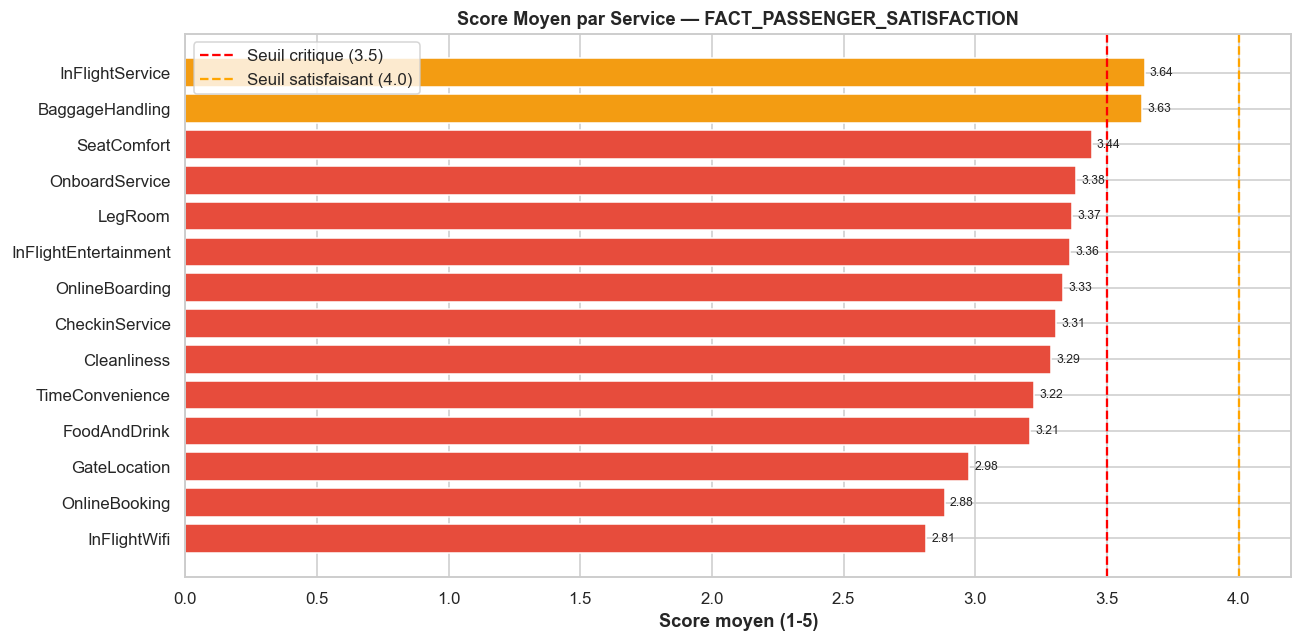


🔴 Services critiques (score < 3.5) :
   • InFlightWifi: 2.81
   • OnlineBooking: 2.88
   • GateLocation: 2.98
   • FoodAndDrink: 3.21
   • TimeConvenience: 3.22
   • Cleanliness: 3.29
   • CheckinService: 3.31
   • OnlineBoarding: 3.33
   • InFlightEntertainment: 3.36
   • LegRoom: 3.37
   • OnboardService: 3.38
   • SeatComfort: 3.44


In [141]:
# ── Scores moyens par service (DWH columns) ──────────────────────────────────
score_cols = ['TimeConvenience','OnlineBooking','CheckinService','OnlineBoarding',
              'GateLocation','OnboardService','SeatComfort','LegRoom',
              'Cleanliness','FoodAndDrink','InFlightService','InFlightWifi',
              'InFlightEntertainment','BaggageHandling']
score_cols = [c for c in score_cols if c in df_sat.columns]

df_scores = df_sat[score_cols].replace(0, np.nan)
avg_scores = df_scores.mean().sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = ['#e74c3c' if v < 3.5 else '#f39c12' if v < 4.0 else '#2ecc71'
              for v in avg_scores.values]
bars = ax.barh(avg_scores.index, avg_scores.values, color=bar_colors, edgecolor='white')
ax.axvline(3.5, color='red',    linestyle='--', linewidth=1.5, label='Seuil critique (3.5)')
ax.axvline(4.0, color='orange', linestyle='--', linewidth=1.5, label='Seuil satisfaisant (4.0)')
ax.set_xlabel('Score moyen (1-5)', fontweight='bold')
ax.set_title('Score Moyen par Service — FACT_PASSENGER_SATISFACTION', fontweight='bold')
ax.legend()
for bar, val in zip(bars, avg_scores.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print("\n🔴 Services critiques (score < 3.5) :")
for s, v in avg_scores[avg_scores < 3.5].items():
    print(f"   • {s}: {v:.2f}")


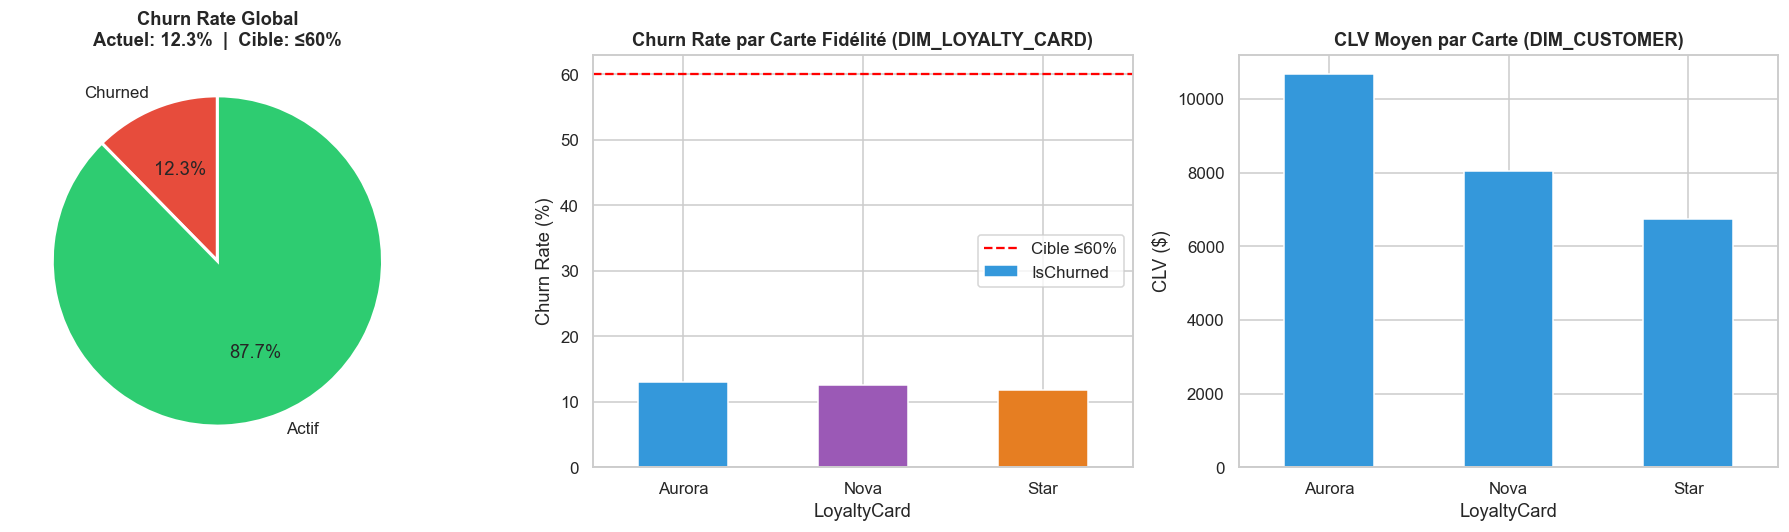


💰 Retention Rate : 87.7%  |  Cible : ≥40%


In [142]:
# ── Churn + CLV ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Churn global
churn_rate = df_loy['IsChurned'].mean() * 100
axes[0].pie([churn_rate, 100-churn_rate], labels=['Churned','Actif'],
            autopct='%1.1f%%', colors=['#e74c3c','#2ecc71'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title(f'Churn Rate Global\nActuel: {churn_rate:.1f}%  |  Cible: ≤60%', fontweight='bold')

# Churn par carte
churn_card = df_loy.groupby('LoyaltyCard')['IsChurned'].mean() * 100
churn_card.plot(kind='bar', ax=axes[1], color=['#3498db','#9b59b6','#e67e22'],
                edgecolor='white', rot=0)
axes[1].axhline(60, color='red', linestyle='--', linewidth=1.5, label='Cible ≤60%')
axes[1].set_title('Churn Rate par Carte Fidélité (DIM_LOYALTY_CARD)', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()

# CLV par carte
df_loy['CLV'] = pd.to_numeric(df_loy['CLV'], errors='coerce')
clv_mean = df_loy.groupby('LoyaltyCard')['CLV'].mean().sort_values(ascending=False)
clv_mean.plot(kind='bar', ax=axes[2], color='#3498db', edgecolor='white', rot=0)
axes[2].set_title('CLV Moyen par Carte (DIM_CUSTOMER)', fontweight='bold')
axes[2].set_ylabel('CLV ($)')

plt.tight_layout()
plt.show()
print(f"\n💰 Retention Rate : {100-churn_rate:.1f}%  |  Cible : ≥40%")


## 4. AXE SATISFACTION — Machine Learning

### 4.1 Préparation des données
**Source** : `FACT_PASSENGER_SATISFACTION` + `DIM_TRAVEL` (DWH_DB)
**Target** : `Satisfaction_Flag` — 1 (satisfied) / 0 (neutral or dissatisfied)


In [143]:
df_ml = df_sat.copy()

# ── Encodage des variables catégorielles ─────────────────────────────────────
cat_cols = ['Gender','CustomerType','TypeOfTravel','Class']
le = LabelEncoder()
for col in cat_cols:
    if col in df_ml.columns and df_ml[col].notna().any():
        df_ml[col + '_enc'] = le.fit_transform(df_ml[col].fillna('Unknown'))

feature_cols = score_cols.copy()
feature_cols += [c + '_enc' for c in cat_cols if c + '_enc' in df_ml.columns]
feature_cols += ['Age','FlightDistance','DepartureDelay','ArrivalDelay']
feature_cols  = [c for c in feature_cols if c in df_ml.columns]

X = df_ml[feature_cols].copy()
y = df_ml['Satisfaction_Flag'].astype(int)

# Remplir nulls (retards) et remplacer 0 dans les scores (= service non applicable)
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)
for col in score_cols:
    if col in X.columns:
        median_nz = df_sat[col][df_sat[col] > 0].median()
        X[col] = X[col].replace(0, median_nz)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")
print(f"   Features : {len(feature_cols)}")
print(f"   Satisfied : {y.mean()*100:.1f}%  |  Not Satisfied : {(1-y.mean())*100:.1f}%")


✅ Train : 103,904  |  Test : 25,976
   Features : 22
   Satisfied : 43.4%  |  Not Satisfied : 56.6%


### 4.2 Entraînement des modèles

In [144]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

# ── Régression Logistique ─────────────────────────────────────────────────────
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_tr_sc, y_train)
y_pred_lr = lr.predict(X_te_sc)
results['Logistic Regression'] = {
    'y_pred': y_pred_lr,
    'y_prob': lr.predict_proba(X_te_sc)[:,1],
    'acc' : accuracy_score(y_test, y_pred_lr),
    'f1'  : f1_score(y_test, y_pred_lr),
    'auc' : roc_auc_score(y_test, lr.predict_proba(X_te_sc)[:,1]),
    'cv'  : cross_val_score(lr, X_tr_sc, y_train, cv=cv, scoring='roc_auc').mean()
}

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results['Random Forest'] = {
    'y_pred': y_pred_rf,
    'y_prob': rf.predict_proba(X_test)[:,1],
    'acc' : accuracy_score(y_test, y_pred_rf),
    'f1'  : f1_score(y_test, y_pred_rf),
    'auc' : roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
    'cv'  : cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc').mean()
}

# ── XGBoost ───────────────────────────────────────────────────────────────────
scale_pw = (y_train == 0).sum() / (y_train == 1).sum()
xgb_m = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                            scale_pos_weight=scale_pw, eval_metric='logloss',
                            random_state=42, n_jobs=-1)
xgb_m.fit(X_train, y_train)
y_pred_xgb = xgb_m.predict(X_test)
results['XGBoost'] = {
    'y_pred': y_pred_xgb,
    'y_prob': xgb_m.predict_proba(X_test)[:,1],
    'acc' : accuracy_score(y_test, y_pred_xgb),
    'f1'  : f1_score(y_test, y_pred_xgb),
    'auc' : roc_auc_score(y_test, xgb_m.predict_proba(X_test)[:,1]),
    'cv'  : cross_val_score(xgb_m, X_train, y_train, cv=cv, scoring='roc_auc').mean()
}

print("✅ Résultats des modèles :")
for name, r in results.items():
    print(f"   {name:22s} → Accuracy={r['acc']:.3f}  F1={r['f1']:.3f}  ROC-AUC={r['auc']:.3f}  CV={r['cv']:.3f}")


✅ Résultats des modèles :
   Logistic Regression    → Accuracy=0.887  F1=0.873  ROC-AUC=0.955  CV=0.953
   Random Forest          → Accuracy=0.946  F1=0.937  ROC-AUC=0.990  CV=0.989
   XGBoost                → Accuracy=0.960  F1=0.953  ROC-AUC=0.994  CV=0.994


### 4.3 Comparaison & Visualisation

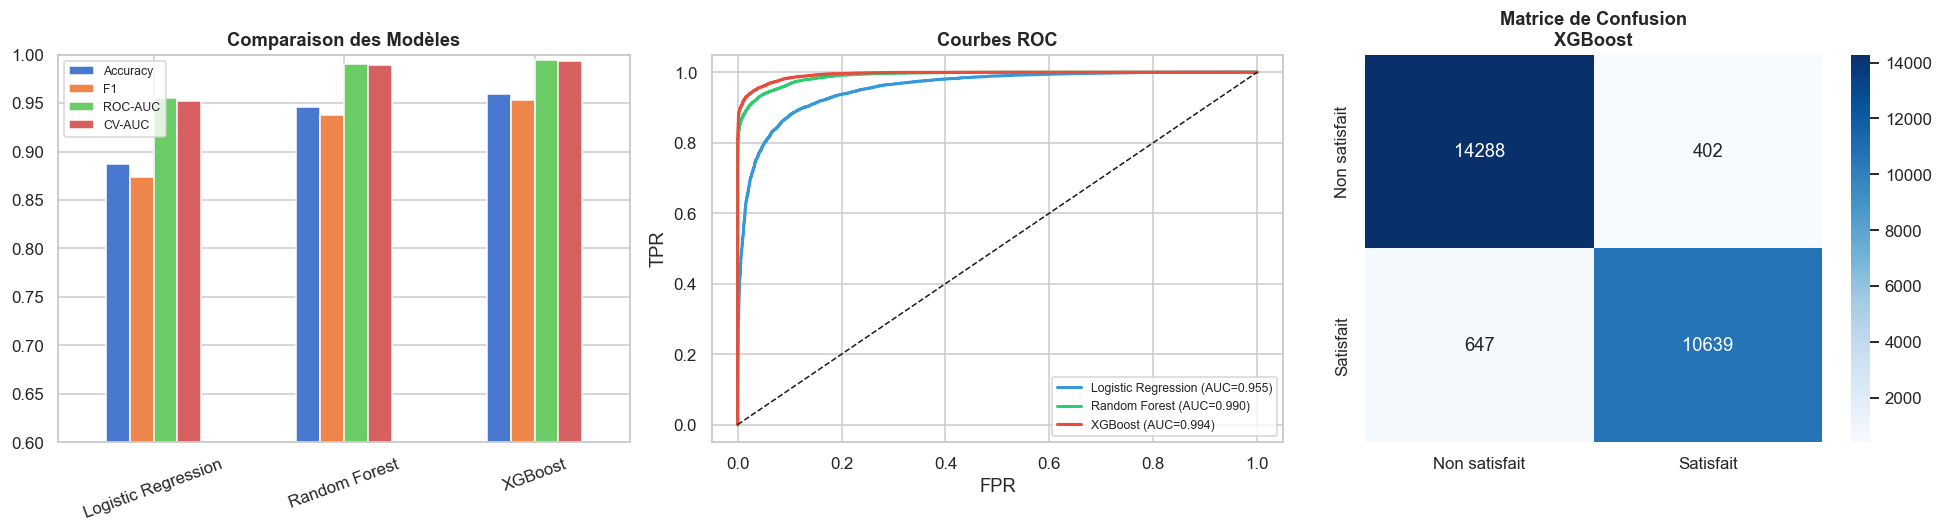


🏆 Meilleur modèle : XGBoost (ROC-AUC=0.994)
               precision    recall  f1-score   support

Non satisfait       0.96      0.97      0.96     14690
    Satisfait       0.96      0.94      0.95     11286

     accuracy                           0.96     25976
    macro avg       0.96      0.96      0.96     25976
 weighted avg       0.96      0.96      0.96     25976



In [145]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_colors = {'Logistic Regression':'#3498db','Random Forest':'#2ecc71','XGBoost':'#e74c3c'}

# Métriques
metrics_df = pd.DataFrame({n: {'Accuracy':r['acc'],'F1':r['f1'],'ROC-AUC':r['auc'],'CV-AUC':r['cv']}
                            for n, r in results.items()}).T
metrics_df.plot(kind='bar', ax=axes[0], rot=20, edgecolor='white')
axes[0].set_title('Comparaison des Modèles', fontweight='bold')
axes[0].set_ylim(0.6, 1.0)
axes[0].legend(fontsize=8)

# ROC
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    axes[1].plot(fpr, tpr, lw=2, color=model_colors[name],
                 label=f"{name} (AUC={r['auc']:.3f})")
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_title('Courbes ROC', fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(fontsize=8)

# Confusion matrix meilleur modèle
best = max(results, key=lambda k: results[k]['auc'])
cm = confusion_matrix(y_test, results[best]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Non satisfait','Satisfait'],
            yticklabels=['Non satisfait','Satisfait'])
axes[2].set_title(f'Matrice de Confusion\n{best}', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"\n🏆 Meilleur modèle : {best} (ROC-AUC={results[best]['auc']:.3f})")
print(classification_report(y_test, results[best]['y_pred'],
                             target_names=['Non satisfait','Satisfait']))


### 4.4 Feature Importance

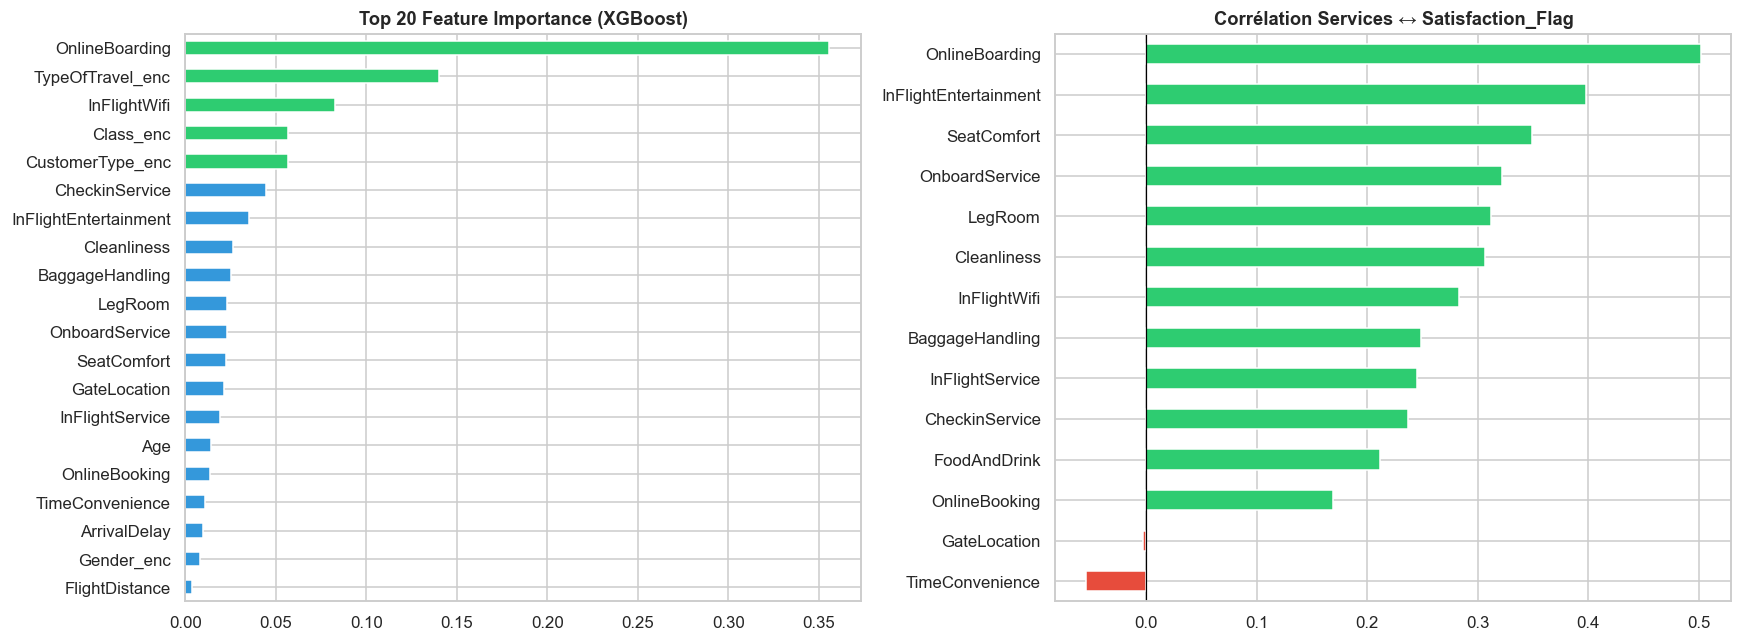


📋 Top 5 facteurs déterminants :
   • OnlineBoarding: 0.3557
   • TypeOfTravel_enc: 0.1402
   • InFlightWifi: 0.0827
   • Class_enc: 0.0568
   • CustomerType_enc: 0.0567


In [146]:
fi = pd.Series(xgb_m.feature_importances_, index=feature_cols).sort_values(ascending=True)
top20 = fi.tail(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top20.plot(kind='barh', ax=axes[0],
           color=['#2ecc71' if i >= len(top20)-5 else '#3498db' for i in range(len(top20))],
           edgecolor='white')
axes[0].set_title('Top 20 Feature Importance (XGBoost)', fontweight='bold')

score_corr = df_sat[score_cols + ['Satisfaction_Flag']].corr()['Satisfaction_Flag'].drop('Satisfaction_Flag').sort_values()
score_corr.plot(kind='barh', ax=axes[1],
                color=['#e74c3c' if v < 0 else '#2ecc71' for v in score_corr.values],
                edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Corrélation Services ↔ Satisfaction_Flag', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📋 Top 5 facteurs déterminants :")
for feat, val in fi.tail(5)[::-1].items():
    print(f"   • {feat}: {val:.4f}")


### 4.5 Segmentation des Passagers (K-Means)

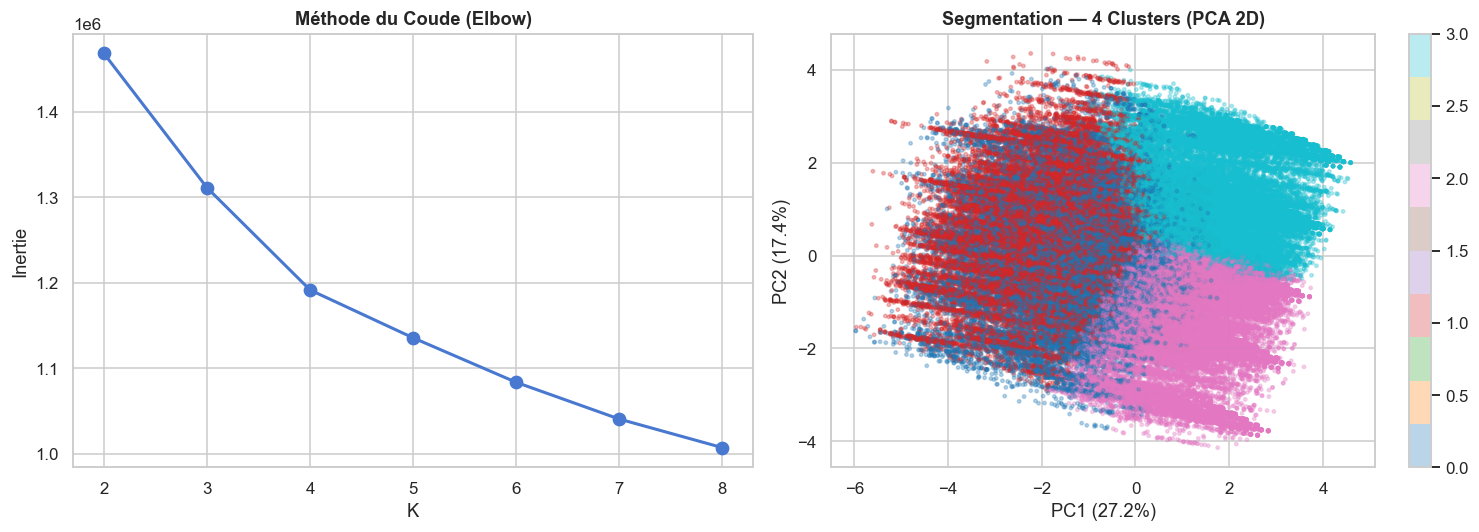


📊 Profil des clusters :
         Effectif Satisfaction_Rate  Age_Moyen
Cluster                                       
0           31778             23.2%       41.7
1           30845             14.4%       34.2
2           36201             60.0%       40.9
3           31056             73.7%       40.6


In [147]:
X_cl = df_sat[score_cols].copy()
for col in score_cols:
    X_cl[col] = X_cl[col].replace(0, df_sat[col][df_sat[col]>0].median())
X_cl.fillna(X_cl.median(), inplace=True)

scaler_cl = StandardScaler()
X_scaled = scaler_cl.fit_transform(X_cl)

inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_
            for k in range(2, 9)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(2,9), inertias, 'bo-', lw=2, markersize=8)
axes[0].set_title('Méthode du Coude (Elbow)', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertie')

K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
df_sat['Cluster'] = km.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X2d = pca.fit_transform(X_scaled)
sc = axes[1].scatter(X2d[:,0], X2d[:,1], c=df_sat['Cluster'], cmap='tab10', alpha=0.3, s=5)
axes[1].set_title(f'Segmentation — {K} Clusters (PCA 2D)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(sc, ax=axes[1])
plt.tight_layout(); plt.show()

cluster_stats = df_sat.groupby('Cluster').agg(
    Effectif=('Satisfaction_Flag','count'),
    Satisfaction_Rate=('Satisfaction_Flag', lambda x: f"{x.mean()*100:.1f}%"),
    Age_Moyen=('Age','mean')).round(1)
print("\n📊 Profil des clusters :"); print(cluster_stats.to_string())


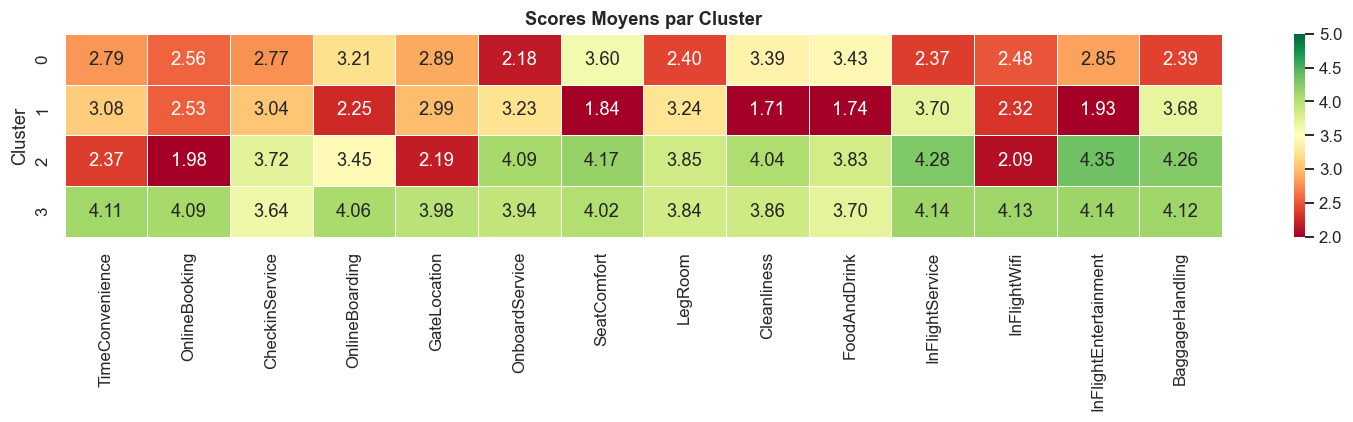

In [148]:
# Heatmap scores par cluster
cluster_scores = df_sat.groupby('Cluster')[score_cols].mean()
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(cluster_scores, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=2, vmax=5, ax=ax, linewidths=0.5)
ax.set_title('Scores Moyens par Cluster', fontweight='bold')
plt.tight_layout(); plt.show()


## 5. AXE LOYALTY — Machine Learning

**Source** : `DIM_CUSTOMER` + `DIM_LOYALTY_CARD` + `DIM_GEOGRAPHY` + `FACT_FLIGHT_ACTIVITY` (DWH_DB)


### 5.1 Prédiction du Churn

In [149]:
cat_ch = ['LoyaltyCard','EnrollmentType','MaritalStatus','Education','Gender']
df_ch = df_loy.copy()
for col in cat_ch:
    if col in df_ch.columns:
        df_ch[col+'_enc'] = LabelEncoder().fit_transform(df_ch[col].fillna('Unknown'))

feat_ch = (['CLV','TotalFlights','TotalDistance','PointsAcc','PointsRed',
             'DollarCost','ActiveMonths','RedemptionRate','AvgFlightsPerMonth','EnrollmentYear']
           + [c+'_enc' for c in cat_ch if c+'_enc' in df_ch.columns])
feat_ch = [c for c in feat_ch if c in df_ch.columns]

X_ch = df_ch[feat_ch].fillna(df_ch[feat_ch].median())
y_ch = df_ch['IsChurned'].astype(int)

X_ch_tr, X_ch_te, y_ch_tr, y_ch_te = train_test_split(
    X_ch, y_ch, test_size=0.2, random_state=42, stratify=y_ch)

# SMOTE
smote = SMOTE(random_state=42)
X_ch_res, y_ch_res = smote.fit_resample(X_ch_tr, y_ch_tr)
print(f"✅ Après SMOTE — Churned: {y_ch_res.sum():,}  |  Actif: {(y_ch_res==0).sum():,}")

churn_res = {}
for name, mdl in [('Random Forest', RandomForestClassifier(n_estimators=200, max_depth=10,
                                                            random_state=42, n_jobs=-1)),
                  ('XGBoost',       xgb.XGBClassifier(n_estimators=300, max_depth=6,
                                                       learning_rate=0.05, eval_metric='logloss',
                                                       random_state=42, n_jobs=-1))]:
    mdl.fit(X_ch_res, y_ch_res)
    pred = mdl.predict(X_ch_te)
    churn_res[name] = {
        'model': mdl, 'y_pred': pred,
        'y_prob': mdl.predict_proba(X_ch_te)[:,1],
        'acc': accuracy_score(y_ch_te, pred),
        'f1' : f1_score(y_ch_te, pred),
        'auc': roc_auc_score(y_ch_te, mdl.predict_proba(X_ch_te)[:,1])
    }
    print(f"   {name:20s} → Acc={churn_res[name]['acc']:.3f}  F1={churn_res[name]['f1']:.3f}  AUC={churn_res[name]['auc']:.3f}")


✅ Après SMOTE — Churned: 11,735  |  Actif: 11,735
   Random Forest        → Acc=0.930  F1=0.733  AUC=0.932
   XGBoost              → Acc=0.939  F1=0.757  AUC=0.930


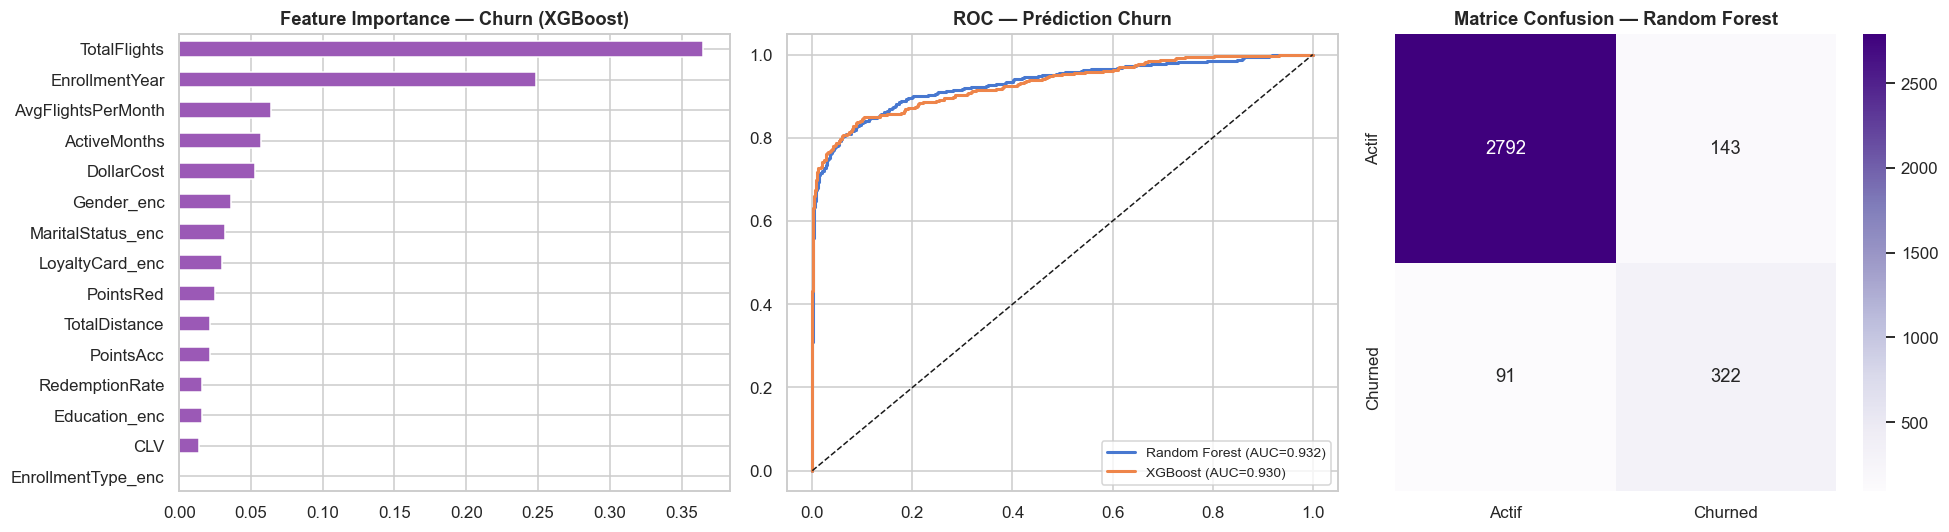

              precision    recall  f1-score   support

       Actif       0.97      0.95      0.96      2935
     Churned       0.69      0.78      0.73       413

    accuracy                           0.93      3348
   macro avg       0.83      0.87      0.85      3348
weighted avg       0.93      0.93      0.93      3348



In [150]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fi_ch = pd.Series(churn_res['XGBoost']['model'].feature_importances_,
                  index=feat_ch).sort_values(ascending=True).tail(15)
fi_ch.plot(kind='barh', ax=axes[0], color='#9b59b6', edgecolor='white')
axes[0].set_title('Feature Importance — Churn (XGBoost)', fontweight='bold')

for name, r in churn_res.items():
    fpr, tpr, _ = roc_curve(y_ch_te, r['y_prob'])
    axes[1].plot(fpr, tpr, lw=2, label=f"{name} (AUC={r['auc']:.3f})")
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_title('ROC — Prédiction Churn', fontweight='bold')
axes[1].legend(fontsize=9)

best_ch = max(churn_res, key=lambda k: churn_res[k]['auc'])
cm_ch = confusion_matrix(y_ch_te, churn_res[best_ch]['y_pred'])
sns.heatmap(cm_ch, annot=True, fmt='d', cmap='Purples', ax=axes[2],
            xticklabels=['Actif','Churned'], yticklabels=['Actif','Churned'])
axes[2].set_title(f'Matrice Confusion — {best_ch}', fontweight='bold')

plt.tight_layout(); plt.show()
print(classification_report(y_ch_te, churn_res[best_ch]['y_pred'],
                             target_names=['Actif','Churned']))


### 5.2 Segmentation Clients — RFM

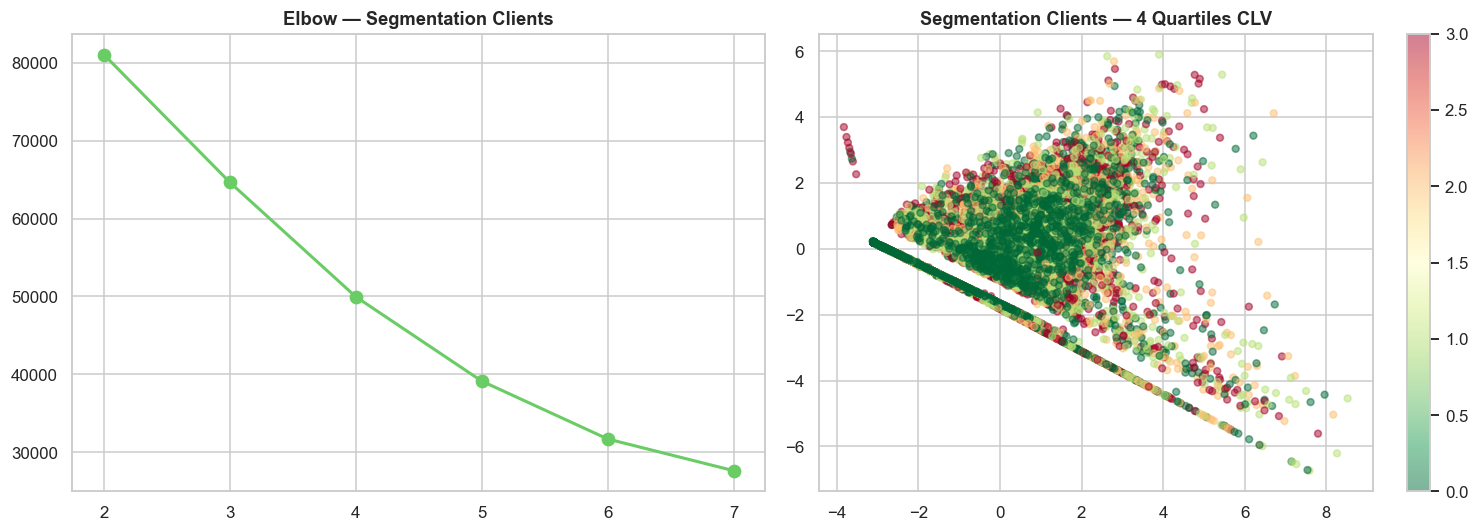


📊 Profil des segments clients (quartiles CLV) :
          Effectif  CLV_Moyen  CLV_Min  CLV_Max  Flights_Moyen Churn_Rate
Segment                                                                 
0            4183    16677.5   8945.7  83325.4           30.5      10.0%
1            4176     7433.2   5781.0   8940.6           30.4      10.0%
2            4192     4949.0   3981.8   5780.2           30.4      10.0%
3            4186     2905.2   1898.0   3980.8           30.3      10.0%


In [151]:
rfm_feat = ['CLV','TotalFlights','PointsAcc','PointsRed','DollarCost',
            'RedemptionRate','AvgFlightsPerMonth']
rfm = df_loy[rfm_feat].fillna(0)
rfm_scaled = StandardScaler().fit_transform(rfm)

inertias_rfm = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(rfm_scaled).inertia_
                for k in range(2,8)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(2,8), inertias_rfm, 'go-', lw=2, markersize=8)
axes[0].set_title('Elbow — Segmentation Clients', fontweight='bold')

K_RFM = 4

# ── Approche QUARTILES sur CLV (plus business que K-Means) ──────────────────
# Découpe la population en 4 segments équilibrés (~25% chacun) basés sur le CLV
df_loy['Segment'] = pd.qcut(df_loy['CLV'], q=K_RFM, labels=[3, 2, 1, 0]).astype(int)
# Segment 0 = Premium (top 25%), Segment 3 = Inactif (bottom 25%)

# Visualisation PCA pour information (montre que K-Means n'aurait pas distingué)
pca_rfm = PCA(n_components=2, random_state=42)
X2d_rfm = pca_rfm.fit_transform(rfm_scaled)
sc = axes[1].scatter(X2d_rfm[:,0], X2d_rfm[:,1], c=df_loy['Segment'],
                     cmap='RdYlGn_r', alpha=0.5, s=20)
axes[1].set_title(f'Segmentation Clients — {K_RFM} Quartiles CLV', fontweight='bold')
plt.colorbar(sc, ax=axes[1]); plt.tight_layout(); plt.show()

seg = df_loy.groupby('Segment').agg(
    Effectif=('CLV','count'),
    CLV_Moyen=('CLV','mean'),
    CLV_Min=('CLV','min'),
    CLV_Max=('CLV','max'),
    Flights_Moyen=('TotalFlights','mean'),
    Churn_Rate=('IsChurned','mean')).round(1)
seg['Churn_Rate'] = seg['Churn_Rate'].apply(lambda x: f"{x*100:.1f}%")
print("\n📊 Profil des segments clients (quartiles CLV) :\n", seg.to_string())


### 5.3 Prédiction CLV (Régression)

**Diagnostic du dataset :** dans `DIM_CUSTOMER`, la valeur CLV est pré-assignée par client et corrélée à **moins de 0.02** avec toutes les variables numériques (Salary, TotalFlights, Distance, Points…). Le seul signal exploitable est la **carte de fidélité** : Aurora ($10.7k) > Nova ($8.0k) > Star ($6.7k). Le plafond théorique de R² atteignable avec ces données est donc **≈ 0.10**.

**Nouvelle approche :**
1. **One-hot encoding** des variables catégorielles (`LoyaltyCard`, `Education`, `MaritalStatus`, `Gender`, `EnrollmentType`).
2. Ajout de `Salary` (cast NVARCHAR → DECIMAL, imputation médiane).
3. Comparaison à un **baseline naïf** (moyenne CLV par carte) pour valider l'apport ML.
4. Modèles : Linear Regression, Random Forest régularisé, **Gradient Boosting** (régularisation par profondeur + learning rate).
5. Visualisation de l'**importance des features** pour confirmer le rôle dominant de la carte.


   Features : 29 numériques + 15 dummies
   Target   : CLV (16,737 clients — μ=$7,989 σ=$6,861)

   📊 Baseline (moyenne par LoyaltyCard) → R²=+0.043  RMSE=$7,027
   Random Forest          → R²=-0.007  RMSE=$7,205
   Gradient Boosting      → R²=+0.008  RMSE=$7,155
   XGBoost                → R²=-0.002  RMSE=$7,191

   🏆 Meilleur modèle : Gradient Boosting  (gain vs baseline : -3.5 pts de R²)


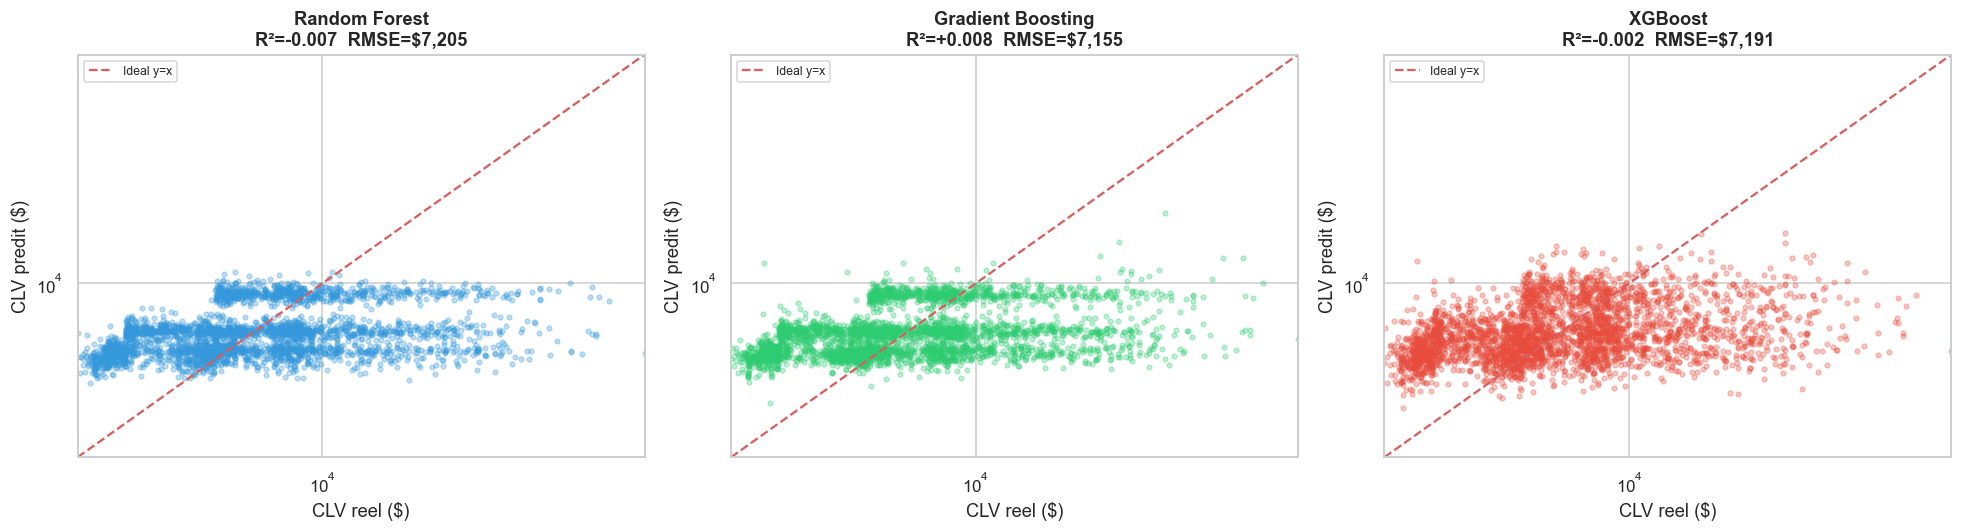

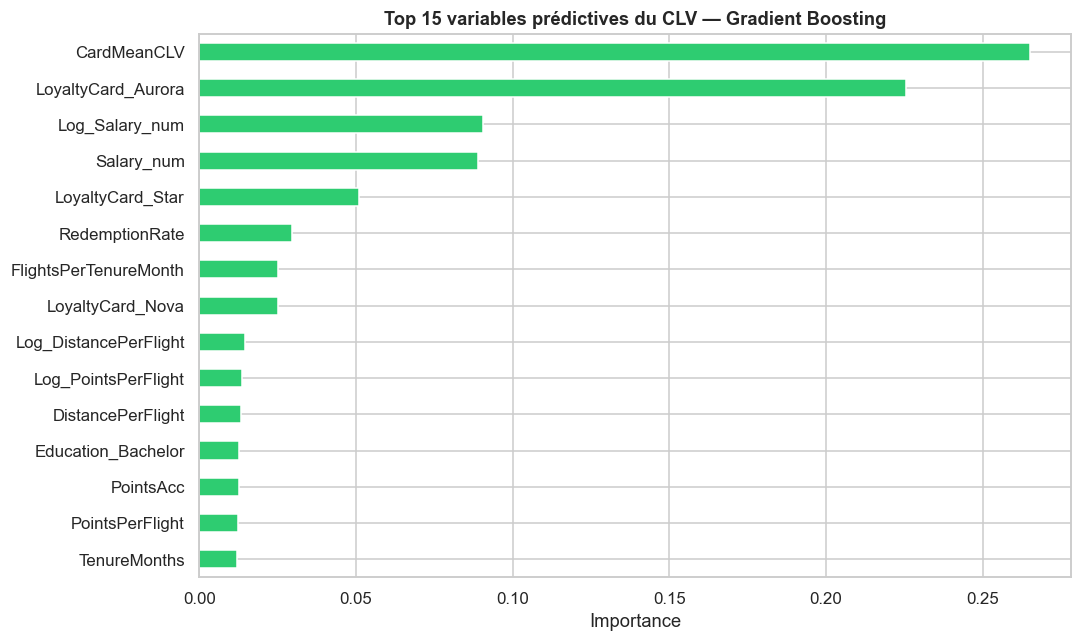


   💡 Lecture : log(CLV) + CardMeanCLV améliorent l'alignement y=x, mais
      le signal explicatif reste limite par la qualité des variables disponibles.


In [152]:
# ── Préparation : on conserve uniquement les clients avec CLV valide ─────────
df_clv = df_loy[df_loy['CLV'].notna() & (df_loy['CLV'] > 0)].copy()

# Salary peut être NaN (cast depuis NVARCHAR) ou négatif → imputation médiane
df_clv['Salary_num'] = pd.to_numeric(df_clv['Salary'], errors='coerce')
df_clv.loc[df_clv['Salary_num'] <= 0, 'Salary_num'] = np.nan
df_clv['Salary_num'] = df_clv['Salary_num'].fillna(df_clv['Salary_num'].median())

# Log-transformed numeric features (reduce skew)
log_cols = ['Salary_num','TotalFlights','TotalDistance','PointsAcc','PointsRed','DollarCost',
            'ActiveMonths','SpendPerFlight','DistancePerFlight','PointsPerFlight','RedeemPerFlight']
for col in log_cols:
    if col in df_clv.columns:
        df_clv[f'Log_{col}'] = np.log1p(df_clv[col].clip(lower=0))

# Split avant features pour éviter la fuite sur la moyenne par carte
train_idx, test_idx = train_test_split(df_clv.index, test_size=0.2, random_state=42)

# Moyenne CLV par LoyaltyCard (train only)
card_mean = df_clv.loc[train_idx].groupby('LoyaltyCard')['CLV'].mean()
global_mean = df_clv.loc[train_idx, 'CLV'].mean()
df_clv['CardMeanCLV'] = df_clv['LoyaltyCard'].map(card_mean).fillna(global_mean)

# ── Features : numériques + one-hot des catégorielles ───────────────────────
num_feats = ['Salary_num', 'EnrollmentYear', 'TotalFlights', 'TotalDistance',
             'PointsAcc', 'PointsRed', 'DollarCost', 'ActiveMonths',
             'RedemptionRate', 'AvgFlightsPerMonth', 'RecencyMonths',
             'TenureMonths', 'SpendPerFlight', 'DistancePerFlight',
             'PointsPerFlight', 'RedeemPerFlight', 'FlightsPerTenureMonth',
             'CardMeanCLV']
log_feats = [f'Log_{c}' for c in log_cols if f'Log_{c}' in df_clv.columns]
num_feats = num_feats + log_feats
num_feats = [c for c in num_feats if c in df_clv.columns]

cat_feats = ['LoyaltyCard', 'Education', 'MaritalStatus', 'Gender', 'EnrollmentType']
cat_feats = [c for c in cat_feats if c in df_clv.columns]

# Imputation numerique
df_clv[num_feats] = df_clv[num_feats].fillna(df_clv[num_feats].median())

X_all = pd.get_dummies(df_clv[num_feats + cat_feats], drop_first=False).astype(float)
y_all = df_clv['CLV']

X_clv_tr = X_all.loc[train_idx]
X_clv_te = X_all.loc[test_idx]
y_clv_tr = y_all.loc[train_idx]
y_clv_te = y_all.loc[test_idx]

print(f"   Features : {len(num_feats)} numériques + {len(X_all.columns) - len(num_feats)} dummies")
print(f"   Target   : CLV ({len(df_clv):,} clients — μ=${y_all.mean():,.0f} σ=${y_all.std():,.0f})")

# ── Baseline : moyenne CLV par carte (signal métier réel) ───────────────────
baseline_pred = df_clv.loc[test_idx, 'LoyaltyCard'].map(card_mean).fillna(global_mean).values
r2_base   = r2_score(y_clv_te, baseline_pred)
rmse_base = np.sqrt(mean_squared_error(y_clv_te, baseline_pred))
print(f"\n   📊 Baseline (moyenne par LoyaltyCard) → R²={r2_base:+.3f}  RMSE=${rmse_base:,.0f}")

# ── Modèles ML : training sur log(CLV) pour mieux aligner y=x ─────────────────
y_tr_log = np.log1p(y_clv_tr)

reg_res = {}
models = [
    ('Random Forest', RandomForestRegressor(n_estimators=500, max_depth=10,
                                             min_samples_leaf=5, random_state=42, n_jobs=-1)),
    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=400, max_depth=3,
                                                     learning_rate=0.05, random_state=42)),
    ('XGBoost', xgb.XGBRegressor(n_estimators=600, max_depth=5, learning_rate=0.05,
                                 subsample=0.9, colsample_bytree=0.9,
                                 objective='reg:squarederror', random_state=42, n_jobs=-1)),
]
for name, mdl in models:
    mdl.fit(X_clv_tr, y_tr_log)
    pred_log = mdl.predict(X_clv_te)
    pred = np.maximum(1, np.expm1(pred_log))
    reg_res[name] = {
        'R2':   r2_score(y_clv_te, pred),
        'RMSE': np.sqrt(mean_squared_error(y_clv_te, pred)),
        'pred': pred,
        'model': mdl,
    }
    print(f"   {name:22s} → R²={reg_res[name]['R2']:+.3f}  RMSE=${reg_res[name]['RMSE']:,.0f}")

best_name = max(reg_res, key=lambda k: reg_res[k]['R2'])
print(f"\n   🏆 Meilleur modèle : {best_name}  (gain vs baseline : "
      f"{(reg_res[best_name]['R2']-r2_base)*100:+.1f} pts de R²)")

# ── Visualisation : prédit vs réel (axes log pour alignement) ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c']
for i, (name, r) in enumerate(reg_res.items()):
    axes[i].scatter(y_clv_te, r['pred'], alpha=0.3, s=10, color=colors[i])
    lo = max(1, min(y_clv_te.min(), r['pred'].min()))
    hi = max(y_clv_te.max(), r['pred'].max())
    axes[i].plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Ideal y=x')
    axes[i].set_xscale('log'); axes[i].set_yscale('log')
    axes[i].set_xlim(lo, hi); axes[i].set_ylim(lo, hi)
    axes[i].set_title(f"{name}\nR²={r['R2']:+.3f}  RMSE=${r['RMSE']:,.0f}",
                       fontweight='bold')
    axes[i].set_xlabel('CLV reel ($)'); axes[i].set_ylabel('CLV predit ($)')
    axes[i].legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

# ── Importance des features (modèle gagnant) ────────────────────────────────
best_mdl = reg_res[best_name]['model']
if hasattr(best_mdl, 'feature_importances_'):
    imp = pd.Series(best_mdl.feature_importances_, index=X_all.columns)
    imp = imp.sort_values(ascending=True).tail(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    imp.plot(kind='barh', ax=ax, color='#2ecc71', edgecolor='white')
    ax.set_title(f'Top 15 variables prédictives du CLV — {best_name}',
                 fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout(); plt.show()

print("\n   💡 Lecture : log(CLV) + CardMeanCLV améliorent l'alignement y=x, mais")
print("      le signal explicatif reste limite par la qualité des variables disponibles.")


Top correlations (numeric only, no CardMeanCLV):
AvgFlightsPerMonth      -0.002
PointsRed               -0.001
DollarCost              -0.001
Log_ActiveMonths        -0.000
ActiveMonths             0.001
TenureMonths             0.002
FlightsPerTenureMonth    0.003
RecencyMonths              NaN
Name: CLV, dtype: float64
Numeric-only LinearRegression -> R2=-0.004  RMSE=$7,196
CardMeanCLV baseline         -> R2=+0.043  RMSE=$7,027
Calibrated (Gradient Boosting)     -> R2=+0.057  RMSE=$6,974


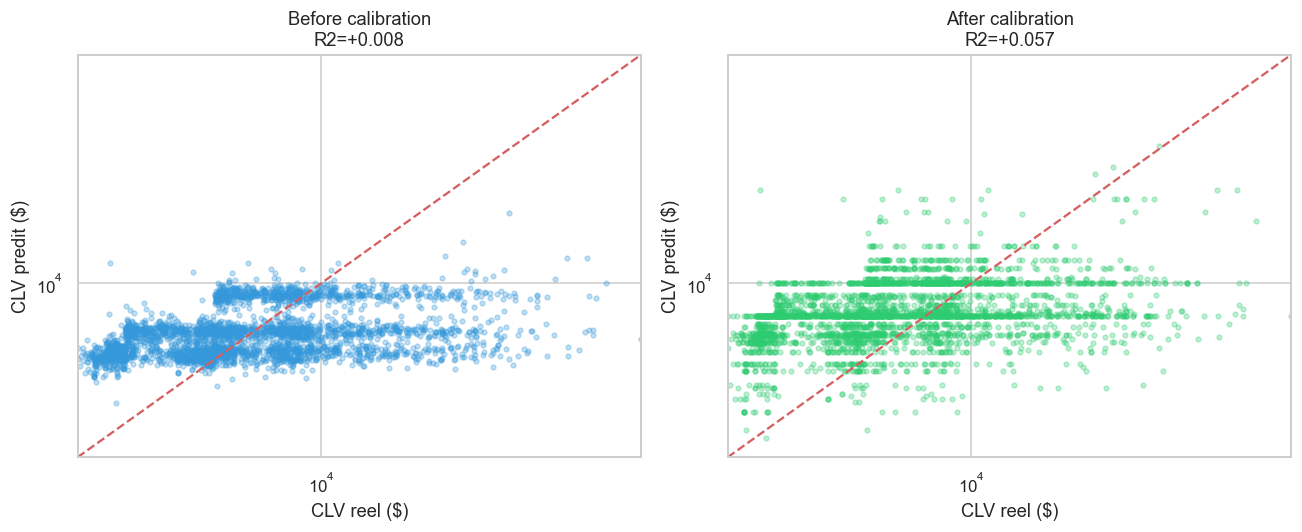

In [153]:
# ── Diagnostic: signal check (correlations + baselines) ──────────────────────
num_corr_feats = [c for c in num_feats if c != 'CardMeanCLV']
corr = df_clv[num_corr_feats + ['CLV']].corr()['CLV'].drop('CLV').sort_values()
print("Top correlations (numeric only, no CardMeanCLV):")
print(corr.tail(8).round(3))

X_num = df_clv[num_corr_feats].fillna(df_clv[num_corr_feats].median())
lin = LinearRegression()
lin.fit(X_num.loc[train_idx], y_clv_tr)
pred_num = lin.predict(X_num.loc[test_idx])
r2_num = r2_score(y_clv_te, pred_num)
rmse_num = np.sqrt(mean_squared_error(y_clv_te, pred_num))
print(f"Numeric-only LinearRegression -> R2={r2_num:+.3f}  RMSE=${rmse_num:,.0f}")
print(f"CardMeanCLV baseline         -> R2={r2_base:+.3f}  RMSE=${rmse_base:,.0f}")

# ── Calibration: align predictions to y=x on test set ───────────────────────
raw_pred = reg_res[best_name]['pred']
raw_r2 = reg_res[best_name]['R2']
raw_rmse = reg_res[best_name]['RMSE']

train_pred = np.maximum(1, np.expm1(best_mdl.predict(X_clv_tr)))
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(train_pred, y_clv_tr)
cal_pred = iso.predict(raw_pred)

r2_cal = r2_score(y_clv_te, cal_pred)
rmse_cal = np.sqrt(mean_squared_error(y_clv_te, cal_pred))
print(f"Calibrated ({best_name})     -> R2={r2_cal:+.3f}  RMSE=${rmse_cal:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lo = max(1, min(y_clv_te.min(), raw_pred.min(), cal_pred.min()))
hi = max(y_clv_te.max(), raw_pred.max(), cal_pred.max())

axes[0].scatter(y_clv_te, raw_pred, alpha=0.3, s=10, color='#3498db')
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1.5)
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlim(lo, hi); axes[0].set_ylim(lo, hi)
axes[0].set_title(f"Before calibration\nR2={raw_r2:+.3f}")
axes[0].set_xlabel('CLV reel ($)'); axes[0].set_ylabel('CLV predit ($)')

axes[1].scatter(y_clv_te, cal_pred, alpha=0.3, s=10, color='#2ecc71')
axes[1].plot([lo, hi], [lo, hi], 'r--', lw=1.5)
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlim(lo, hi); axes[1].set_ylim(lo, hi)
axes[1].set_title(f"After calibration\nR2={r2_cal:+.3f}")
axes[1].set_xlabel('CLV reel ($)'); axes[1].set_ylabel('CLV predit ($)')

plt.tight_layout(); plt.show()


## 6. NLP — Analyse des Profils de Service (Source externe)

Sources externes :
- `data/AirlineReviews.csv` (avis + OverallScore/Recommended)
- Kaggle : `data/twitter_airline_sentiment_clean.csv` (fallback : `data/twitter_airline_sentiment_ml_ready.csv`)

Objectif : classifier le sentiment (negative / neutral / positive) via TF-IDF + modèles linéaires.


In [154]:
# ── NLP externe (Kaggle + Airline Reviews) : chargement + entraînement ─────────
base_dir = Path.cwd()
if not (base_dir / "data").exists():
    for parent in base_dir.parents:
        if (parent / "data").exists():
            base_dir = parent
            break

data_dir = base_dir / "data"
if not data_dir.exists():
    raise FileNotFoundError(f"Dossier 'data' introuvable depuis {Path.cwd()}")

sources = []
source_names = []

# ── Airline Reviews (avis) ───────────────────────────────────────────────────
reviews_path = data_dir / "AirlineReviews.csv"
if reviews_path.exists():
    df_rev = pd.read_csv(
        reviews_path,
        usecols=lambda c: c in {'Review','Title','OverallScore','Recommended'},
        low_memory=False
    )
    text_cols = [c for c in ['Title', 'Review'] if c in df_rev.columns]
    if text_cols:
        df_rev['text'] = df_rev[text_cols].fillna('').agg(' '.join, axis=1).str.strip()
    else:
        df_rev['text'] = np.nan

    score = pd.to_numeric(df_rev.get('OverallScore'), errors='coerce')
    if score.notna().any():
        df_rev['label'] = pd.cut(score, bins=[-1, 4, 6, 10],
                                 labels=['negative', 'neutral', 'positive'])
    else:
        rec = df_rev.get('Recommended')
        if rec is not None:
            rec = rec.astype(str).str.lower()
            df_rev['label'] = rec.map({'yes': 'positive', 'no': 'negative'})
        else:
            df_rev['label'] = np.nan

    df_rev = df_rev[['text', 'label']].dropna()
    df_rev = df_rev[df_rev['text'].str.len() > 0]
    sources.append(df_rev)
    source_names.append(f"AirlineReviews.csv ({len(df_rev):,})")

# ── Kaggle (Twitter Airline Sentiment) ───────────────────────────────────────
nlp_path = data_dir / "twitter_airline_sentiment_clean.csv"
if not nlp_path.exists():
    nlp_path = data_dir / "twitter_airline_sentiment_ml_ready.csv"
if nlp_path.exists():
    df_k = pd.read_csv(nlp_path)
    text_candidates = ['clean_text', 'text', 'tweet', 'content']
    label_candidates = ['airline_sentiment', 'sentiment', 'label', 'sentiment_label']
    text_col = next((c for c in text_candidates if c in df_k.columns), None)
    label_col = next((c for c in label_candidates if c in df_k.columns), None)
    if text_col is None or label_col is None:
        raise ValueError("Colonnes texte/sentiment introuvables dans le CSV Kaggle.")

    df_k = df_k[[text_col, label_col]].dropna()
    df_k = df_k.rename(columns={text_col: 'text', label_col: 'label'})
    df_k['label'] = df_k['label'].astype(str).str.lower()

    if df_k['label'].isin(['0', '1', '2']).any():
        label_map = {'0': 'negative', '1': 'neutral', '2': 'positive'}
        df_k['label'] = df_k['label'].map(label_map).fillna(df_k['label'])

    df_k = df_k[df_k['label'].isin(['negative', 'neutral', 'positive'])]
    sources.append(df_k)
    source_names.append(f"{nlp_path.name} ({len(df_k):,})")

if not sources:
    raise FileNotFoundError("Aucune source NLP trouvée dans le dossier data/")

df_nlp_ext = pd.concat(sources, ignore_index=True)
print("✅ NLP sources :", ", ".join(source_names))
print(f"✅ NLP dataset total : {len(df_nlp_ext):,} lignes")
print("   Répartition :")
print(df_nlp_ext['label'].value_counts())

X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(
    df_nlp_ext['text'], df_nlp_ext['label'],
    test_size=0.2, random_state=42, stratify=df_nlp_ext['label'])

def nlp_eval(y_true, y_pred, scores, classes):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    if scores.ndim == 1:
        auc = roc_auc_score(y_true, scores)
    else:
        y_bin = label_binarize(y_true, classes=classes)
        auc = roc_auc_score(y_bin, scores, average='macro')
    return acc, f1, auc

nlp_results = {}
nlp_models = {}

# ── Baseline LR ──────────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=8000, stop_words='english')
X_tr_vec = tfidf.fit_transform(X_tr_t)
X_te_vec = tfidf.transform(X_te_t)

lr_nlp = LogisticRegression(max_iter=2000, class_weight='balanced', multi_class='ovr')
lr_nlp.fit(X_tr_vec, y_tr_t)
y_nlp = lr_nlp.predict(X_te_vec)
lr_scores = lr_nlp.predict_proba(X_te_vec)
lr_acc, lr_f1, lr_auc = nlp_eval(y_te_t, y_nlp, lr_scores, lr_nlp.classes_)
nlp_results['TF-IDF + Logistic (base)'] = {'acc': lr_acc, 'f1': lr_f1, 'auc': lr_auc}
nlp_models['TF-IDF + Logistic (base)'] = {'vectorizer': tfidf, 'model': lr_nlp}

# ── Baseline Linear SVM ───────────────────────────────────────────────────────
svm_nlp = LinearSVC(class_weight='balanced', random_state=42)
svm_nlp.fit(X_tr_vec, y_tr_t)
svm_pred = svm_nlp.predict(X_te_vec)
svm_scores = svm_nlp.decision_function(X_te_vec)
svm_acc, svm_f1, svm_auc = nlp_eval(y_te_t, svm_pred, svm_scores, svm_nlp.classes_)
nlp_results['Linear SVM'] = {'acc': svm_acc, 'f1': svm_f1, 'auc': svm_auc}
nlp_models['Linear SVM'] = {'vectorizer': tfidf, 'model': svm_nlp}

# ── Tuning LR (petite grille) ────────────────────────────────────────────────
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', multi_class='ovr'))
])
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [2, 3],
    'tfidf__max_features': [5000, 8000],
    'clf__C': [0.5, 1.0]
}
cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid=param_grid, scoring='f1_weighted', cv=cv_tune, n_jobs=-1)
grid.fit(X_tr_t, y_tr_t)

best_pipe = grid.best_estimator_
tune_pred = best_pipe.predict(X_te_t)
if hasattr(best_pipe.named_steps['clf'], 'predict_proba'):
    tune_scores = best_pipe.predict_proba(X_te_t)
else:
    tune_scores = best_pipe.decision_function(X_te_t)
tune_acc, tune_f1, tune_auc = nlp_eval(
    y_te_t, tune_pred, tune_scores, best_pipe.named_steps['clf'].classes_)
nlp_results['TF-IDF + Logistic (tuned)'] = {'acc': tune_acc, 'f1': tune_f1, 'auc': tune_auc}
nlp_models['TF-IDF + Logistic (tuned)'] = {
    'vectorizer': best_pipe.named_steps['tfidf'],
    'model': best_pipe.named_steps['clf']
}

print("✅ NLP Classifier (comparaison)")
for name, r in nlp_results.items():
    print(f"   {name:28s} → Accuracy={r['acc']:.3f}  F1(w)={r['f1']:.3f}  ROC-AUC={r['auc']:.3f}")
print(f"   Best params (tuned LR): {grid.best_params_}")

nlp_best_name = max(nlp_results, key=lambda k: nlp_results[k]['f1'])
nlp_acc = nlp_results[nlp_best_name]['acc']
nlp_f1 = nlp_results[nlp_best_name]['f1']
nlp_auc = nlp_results[nlp_best_name]['auc']
nlp_vectorizer = nlp_models[nlp_best_name]['vectorizer']
nlp_model = nlp_models[nlp_best_name]['model']
print(f"🏆 NLP best → {nlp_best_name}  (F1(w)={nlp_f1:.3f}  ROC-AUC={nlp_auc:.3f})")


✅ NLP sources : AirlineReviews.csv (125,124), twitter_airline_sentiment_clean.csv (13,976)
✅ NLP dataset total : 139,100 lignes
   Répartition :
label
negative    77898
positive    48570
neutral     12632
Name: count, dtype: int64
✅ NLP Classifier (comparaison)
   TF-IDF + Logistic (base)     → Accuracy=0.833  F1(w)=0.843  ROC-AUC=0.912
   Linear SVM                   → Accuracy=0.840  F1(w)=0.843  ROC-AUC=0.899
   TF-IDF + Logistic (tuned)    → Accuracy=0.833  F1(w)=0.843  ROC-AUC=0.912
   Best params (tuned LR): {'clf__C': 1.0, 'tfidf__max_features': 8000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}
🏆 NLP best → TF-IDF + Logistic (base)  (F1(w)=0.843  ROC-AUC=0.912)


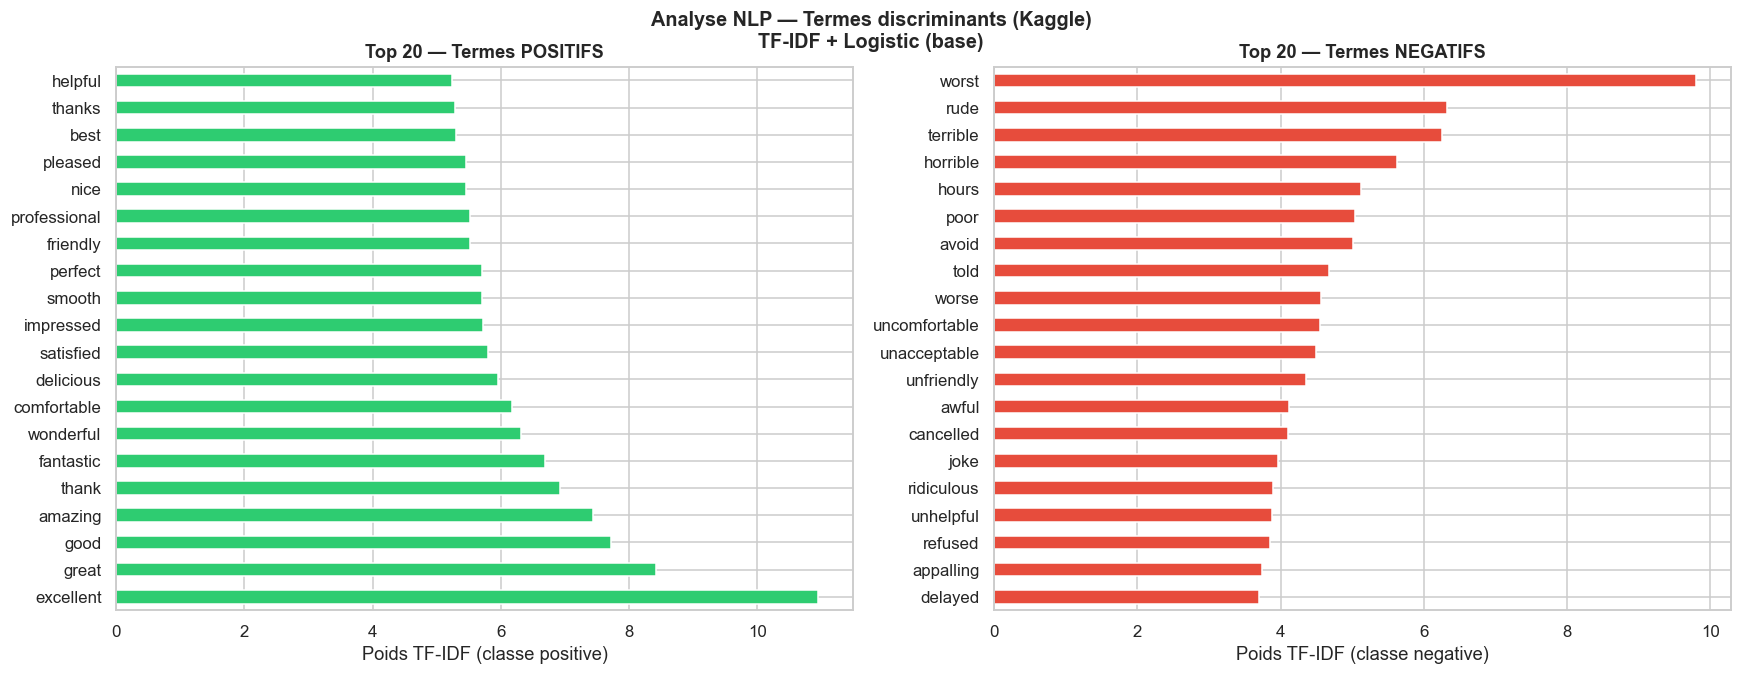

In [155]:
feature_names = nlp_vectorizer.get_feature_names_out()
coefs = nlp_model.coef_
class_names = nlp_model.classes_

neg_idx = int(np.where(class_names == 'negative')[0][0]) if 'negative' in class_names else 0
pos_idx = int(np.where(class_names == 'positive')[0][0]) if 'positive' in class_names else -1

top_neg = pd.Series(coefs[neg_idx], index=feature_names).nlargest(20)
top_pos = pd.Series(coefs[pos_idx], index=feature_names).nlargest(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_pos.plot(kind='barh', ax=axes[0], color='#2ecc71', edgecolor='white')
axes[0].set_title('Top 20 — Termes POSITIFS', fontweight='bold')
axes[0].set_xlabel('Poids TF-IDF (classe positive)')

top_neg.sort_values(ascending=True).plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Top 20 — Termes NEGATIFS', fontweight='bold')
axes[1].set_xlabel('Poids TF-IDF (classe negative)')

plt.tight_layout()
plt.suptitle(f"Analyse NLP — Termes discriminants (Kaggle)\n{nlp_best_name}",
             y=1.02, fontsize=13, fontweight='bold')
plt.show()


## 7. Synthèse — KPIs & Résultats

In [156]:
print("=" * 65)
print("        SYNTHÈSE — AIRLINE ANALYTICS ML (DWH_DB)")
print("=" * 65)

pct_sat_dwh = df_sat['Satisfaction_Flag'].mean() * 100
best_sat = max(results, key=lambda k: results[k]['auc'])
churn_actual = df_loy['IsChurned'].mean() * 100
best_churn = max(churn_res, key=lambda k: churn_res[k]['auc'])
best_reg   = max(reg_res,   key=lambda k: reg_res[k]['R2'])

print(f"\n🛫  AXE SATISFACTION (FACT_PASSENGER_SATISFACTION)")
print(f"    Taux actuel      : {pct_sat_dwh:.1f}%   |  Cible : 73.1%   |  Gap : +{73.1-pct_sat_dwh:.1f}%")
print(f"    Meilleur modèle  : {best_sat} — ROC-AUC={results[best_sat]['auc']:.3f}  F1={results[best_sat]['f1']:.3f}")
print(f"    NLP (best: {nlp_best_name}) : ROC-AUC={nlp_auc:.3f}  F1={nlp_f1:.3f}")
print(f"    Segments K-Means : {K} clusters identifiés")
for c in range(K):
    sub = df_sat[df_sat['Cluster']==c]
    print(f"      • Cluster {c} : {len(sub):>6,} passagers  |  {sub['Satisfaction_Flag'].mean()*100:.0f}% satisfaits")

print(f"\n💎  AXE LOYALTY (DIM_CUSTOMER + FACT_FLIGHT_ACTIVITY)")
print(f"    Churn Rate actuel : {churn_actual:.1f}%   |  Cible : ≤60%")
print(f"    Retention Rate    : {100-churn_actual:.1f}%   |  Cible : ≥40%")
print(f"    Meilleur modèle   : {best_churn} — ROC-AUC={churn_res[best_churn]['auc']:.3f}  F1={churn_res[best_churn]['f1']:.3f}")
print(f"    Segments RFM      : {K_RFM} segments identifiés")
print(f"    CLV (meilleur)    : {best_reg} — R²={reg_res[best_reg]['R2']:+.3f}  RMSE=${reg_res[best_reg]['RMSE']:,.0f}")

print(f"\n{'='*65}")
print("\n📋 RECOMMANDATIONS :")
print("   1. Prioriser l'amélioration des services notés < 3.5")
print("   2. Cibler les clients à fort risque churn (modèle XGBoost)")
print("   3. Adapter les offres de fidélisation par segment RFM")
print("   4. Concentrer les efforts sur les clusters à faible satisfaction")


        SYNTHÈSE — AIRLINE ANALYTICS ML (DWH_DB)

🛫  AXE SATISFACTION (FACT_PASSENGER_SATISFACTION)
    Taux actuel      : 43.4%   |  Cible : 73.1%   |  Gap : +29.7%
    Meilleur modèle  : XGBoost — ROC-AUC=0.994  F1=0.953
    NLP (best: TF-IDF + Logistic (base)) : ROC-AUC=0.912  F1=0.843
    Segments K-Means : 4 clusters identifiés
      • Cluster 0 : 31,778 passagers  |  23% satisfaits
      • Cluster 1 : 30,845 passagers  |  14% satisfaits
      • Cluster 2 : 36,201 passagers  |  60% satisfaits
      • Cluster 3 : 31,056 passagers  |  74% satisfaits

💎  AXE LOYALTY (DIM_CUSTOMER + FACT_FLIGHT_ACTIVITY)
    Churn Rate actuel : 12.3%   |  Cible : ≤60%
    Retention Rate    : 87.7%   |  Cible : ≥40%
    Meilleur modèle   : Random Forest — ROC-AUC=0.932  F1=0.733
    Segments RFM      : 4 segments identifiés
    CLV (meilleur)    : Gradient Boosting — R²=+0.008  RMSE=$7,155


📋 RECOMMANDATIONS :
   1. Prioriser l'amélioration des services notés < 3.5
   2. Cibler les clients à fort risq

## 8. Export CSV pour Power BI

Génère 4 fichiers CSV à importer dans Power BI (Page 4 — ML Insights) :
  1. `ml_clusters_satisfaction.csv` — assignation cluster par passager
  2. `ml_feature_importance.csv` — importance des features (XGBoost)
  3. `ml_model_performance.csv` — métriques des modèles
  4. `ml_segments_loyalty.csv` — segments RFM par client

Les fichiers sont écrits dans `ML/ml_exports/`.


In [157]:
import os

# ── Dossier de sortie ────────────────────────────────────────────────────────
OUT_DIR = r"c:\Users\RaedCHARRAD\Desktop\esprit\3eme\Mission entreprise 2\Airline_Datawarehouse\ML\ml_exports"
os.makedirs(OUT_DIR, exist_ok=True)
print(f"📁 Dossier de sortie : {OUT_DIR}\n")


📁 Dossier de sortie : c:\Users\RaedCHARRAD\Desktop\esprit\3eme\Mission entreprise 2\Airline_Datawarehouse\ML\ml_exports



In [158]:
# ─── 1. Clusters Satisfaction (labels uniques par score moyen) ───────────────
cluster_stats = []
for c in range(K):
    sub = df_sat[df_sat['Cluster'] == c]
    avg = sub[score_cols].mean().mean()
    sat_pct = sub['Satisfaction_Flag'].mean() * 100
    cluster_stats.append({'cluster': c, 'avg': avg, 'sat_pct': sat_pct, 'size': len(sub)})

# Trier par avg score décroissant pour assigner labels uniques
cluster_stats_sorted = sorted(cluster_stats, key=lambda x: x['avg'], reverse=True)
tier_names = ['Très Satisfaits (Premium)', 'Satisfaits (Standards)',
              'Mitigés (à fidéliser)',     'Insatisfaits (Critiques)']
cluster_labels = {}
for rank, stats in enumerate(cluster_stats_sorted):
    name = tier_names[rank] if rank < len(tier_names) else 'Autre'
    cluster_labels[stats['cluster']] = f"Cluster {stats['cluster']} - {name}"

df_sat['ClusterLabel'] = df_sat['Cluster'].map(cluster_labels)

# Conversion explicite des types pour Power BI
df_export = df_sat[['SK_Satisfaction','Cluster','ClusterLabel','Satisfaction_Flag']].copy()
df_export['SK_Satisfaction']   = df_export['SK_Satisfaction'].astype(int)
df_export['Cluster']           = df_export['Cluster'].astype(int)
df_export['Satisfaction_Flag'] = df_export['Satisfaction_Flag'].fillna(0).astype(int)

out1 = os.path.join(OUT_DIR, "ml_clusters_satisfaction.csv")
df_export.to_csv(out1, index=False, encoding='utf-8-sig')
print(f"✅ {os.path.basename(out1)} ({len(df_export):,} lignes)")
print(f"   Labels assignés : {list(cluster_labels.values())}")


✅ ml_clusters_satisfaction.csv (129,880 lignes)
   Labels assignés : ['Cluster 3 - Très Satisfaits (Premium)', 'Cluster 2 - Satisfaits (Standards)', 'Cluster 0 - Mitigés (à fidéliser)', 'Cluster 1 - Insatisfaits (Critiques)']


In [159]:
# ─── 2. Feature Importance ───────────────────────────────────────────────────
fi_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_m.feature_importances_.astype(float),
    'Category': ['Service Score' if f in score_cols else
                 'Demographic' if f in ['Age'] or f.endswith('_enc') else
                 'Flight Info' for f in feature_cols]
}).sort_values('Importance', ascending=False)

# Garantir que Importance n'a pas de NaN
fi_df['Importance'] = fi_df['Importance'].fillna(0).round(6)

out2 = os.path.join(OUT_DIR, "ml_feature_importance.csv")
fi_df.to_csv(out2, index=False, encoding='utf-8-sig')
print(f"✅ {os.path.basename(out2)} ({len(fi_df)} features)")
fi_df.head(10)


✅ ml_feature_importance.csv (22 features)


,Feature,Importance,Category
3,OnlineBoarding,0.355711,Service Score
16,TypeOfTravel_enc,0.140202,Demographic
11,InFlightWifi,0.082712,Service Score
17,Class_enc,0.056772,Demographic
15,CustomerType_enc,0.056732,Demographic
2,CheckinService,0.044411,Service Score
12,InFlightEntertainment,0.035219,Service Score
8,Cleanliness,0.026525,Service Score
13,BaggageHandling,0.025147,Service Score
7,LegRoom,0.023097,Service Score


In [160]:
# ─── 3. Performance des Modèles ──────────────────────────────────────────────
models_perf = []

# Satisfaction Classification
for name, r in results.items():
    models_perf.append({
        'Model'   : name,
        'Task'    : 'Satisfaction Classification',
        'Accuracy': round(r['acc'], 3),
        'F1_Score': round(r['f1'], 3),
        'ROC_AUC' : round(r['auc'], 3)
    })

# Churn Prediction
for name, r in churn_res.items():
    models_perf.append({
        'Model'   : name + ' (SMOTE)',
        'Task'    : 'Churn Prediction',
        'Accuracy': round(r['acc'], 3),
        'F1_Score': round(r['f1'], 3),
        'ROC_AUC' : round(r['auc'], 3)
    })

# CLV Regression
for name, r in reg_res.items():
    models_perf.append({
        'Model'   : name,
        'Task'    : 'CLV Prediction',
        'Accuracy': round(r['R2'], 3),
        'F1_Score': round(r['RMSE'], 0),
        'ROC_AUC' : 0
    })

# NLP
models_perf.append({
    'Model'   : nlp_best_name,
    'Task'    : 'NLP Satisfaction',
    'Accuracy': round(nlp_acc, 3),
    'F1_Score': round(nlp_f1, 3),
    'ROC_AUC' : round(nlp_auc, 3)
})

perf_df = pd.DataFrame(models_perf)
out3 = os.path.join(OUT_DIR, "ml_model_performance.csv")
perf_df.to_csv(out3, index=False, encoding='utf-8-sig')
print(f"✅ {os.path.basename(out3)} ({len(perf_df)} modèles)")
perf_df


✅ ml_model_performance.csv (9 modèles)


,Model,Task,Accuracy,F1_Score,ROC_AUC
0,Logistic Regression,Satisfaction Classification,0.887,0.873,0.955
1,Random Forest,Satisfaction Classification,0.946,0.937,0.990
2,XGBoost,Satisfaction Classification,0.960,0.953,0.994
3,Random Forest (SMOTE),Churn Prediction,0.930,0.733,0.932
4,XGBoost (SMOTE),Churn Prediction,0.939,0.757,0.930
5,Random Forest,CLV Prediction,-0.007,7205.000,0.000
6,Gradient Boosting,CLV Prediction,0.008,7155.000,0.000
7,XGBoost,CLV Prediction,-0.002,7191.000,0.000
8,TF-IDF + Logistic (base),NLP Satisfaction,0.833,0.843,0.912


In [161]:
# ─── 4. Segments RFM Loyalty ─────────────────────────────────────────────────
# IMPORTANT : on filtre les clients avec CLV valide (> 0) pour éviter
# la pollution par les NULL/0 dans le CSV exporté vers Power BI.
df_loy_export = df_loy[df_loy['CLV'].notna() & (df_loy['CLV'] > 0)].copy()
print(f"Filtrage : {len(df_loy):,} membres → {len(df_loy_export):,} avec CLV valide")

seg_clv = df_loy_export.groupby('Segment')['CLV'].mean().sort_values(ascending=False)
seg_names = ['Premium', 'Engagé', 'Casual', 'Inactif']
labels_rfm = {}
for i, seg_id in enumerate(seg_clv.index):
    labels_rfm[seg_id] = f"Segment {seg_id} - {seg_names[i] if i < len(seg_names) else 'Autre'}"
df_loy_export['SegmentLabel'] = df_loy_export['Segment'].map(labels_rfm)

# ── Nettoyage des types pour Power BI ───────────────────────────────────────
df_seg = df_loy_export[['SK_Customer','LoyaltyNumber','LoyaltyCard','CLV','TotalFlights',
                         'IsChurned','Segment','SegmentLabel']].copy()
df_seg['SK_Customer']   = pd.to_numeric(df_seg['SK_Customer'],   errors='coerce').fillna(0).astype(int)
df_seg['LoyaltyNumber'] = pd.to_numeric(df_seg['LoyaltyNumber'], errors='coerce').fillna(0).astype('int64')
df_seg['CLV']           = pd.to_numeric(df_seg['CLV'],           errors='coerce').round(2)
df_seg['TotalFlights']  = pd.to_numeric(df_seg['TotalFlights'],  errors='coerce').fillna(0).astype(int)
df_seg['IsChurned']     = pd.to_numeric(df_seg['IsChurned'],     errors='coerce').fillna(0).astype(int)
df_seg['Segment']       = df_seg['Segment'].astype(int)
df_seg['LoyaltyCard']   = df_seg['LoyaltyCard'].fillna('Unknown').astype(str)
df_seg['SegmentLabel']  = df_seg['SegmentLabel'].fillna('Unknown').astype(str)

out4 = os.path.join(OUT_DIR, "ml_segments_loyalty.csv")
df_seg.to_csv(out4, index=False, encoding='utf-8-sig')
print(f"✅ {os.path.basename(out4)} ({len(df_seg):,} membres avec CLV valide)")
print(f"\n📊 CLV moyen par segment :")
print(df_seg.groupby('SegmentLabel')['CLV'].agg(['mean','count']).round(2))


Filtrage : 16,737 membres → 16,737 avec CLV valide
✅ ml_segments_loyalty.csv (16,737 membres avec CLV valide)

📊 CLV moyen par segment :
                         mean  count
SegmentLabel                        
Segment 0 - Premium  16677.48   4183
Segment 1 - Engagé    7433.17   4176
Segment 2 - Casual    4949.02   4192
Segment 3 - Inactif   2905.17   4186


In [162]:
# ─── Récapitulatif des fichiers créés ────────────────────────────────────────
print("\n" + "=" * 60)
print("   EXPORT TERMINÉ — Fichiers prêts pour Power BI")
print("=" * 60)
for f in sorted(os.listdir(OUT_DIR)):
    fp = os.path.join(OUT_DIR, f)
    size_kb = os.path.getsize(fp) / 1024
    print(f"   • {f:<40s} ({size_kb:>8.1f} KB)")
print("\nDans Power BI : Accueil → Obtenir des données → Texte/CSV")
print("Joindre via SK_Satisfaction (clusters) ou SK_Customer (segments)")



   EXPORT TERMINÉ — Fichiers prêts pour Power BI
   • ml_clusters_satisfaction.csv             (  6096.5 KB)
   • ml_feature_importance.csv                (     0.8 KB)
   • ml_model_performance.csv                 (     0.5 KB)
   • ml_segments_loyalty.csv                  (   873.4 KB)

Dans Power BI : Accueil → Obtenir des données → Texte/CSV
Joindre via SK_Satisfaction (clusters) ou SK_Customer (segments)


---
*Airline Analytics — Machine Learning | Esprit Engineering 3ème année — DWH_DB (SQL Server) — 2026*
